# SMT Competition 2026 - Analysis Code Notebook
## Team Number 063

In [1]:
# Importing necessary Python libraries

import pandas as pd
import numpy as np
import pyarrow.dataset as pads
import polars as pl
import matplotlib.pyplot as plt
from sportypy.surfaces import MiLBField
from matplotlib.patches import Rectangle, Arc
from SMT_Data_Starter import readDataSubset

# Exploring the Data / Missingness Checks

# Reading in each major dataset
- ### The reading in code blocks for each dataset are based on the code sample provided in the Python starter code for this competition.
- ### You will also notice that I will be swapping back and forth between using Pandas and Polars dataframes (dataframes is essentially another word for tables). Those two titles simply refer to two different types of tables, where Pandas is more efficient for evaluating code immediately and working with smaller subsets of data, while Polars is more efficient for working with larger datasets.

### Game-info dataset containing general matchup information for each game in the data

In [2]:
# Reading in game-info dataset
game_info_df = readDataSubset('game-info')

# Define criteria to filter data subset on
# You may pass this directly to the `filter` argument of `to_table()` if you choose
#filter_criteria = (pads.field('game_string') == "y1_d061_VKA_PHD")

# Apply your row filters and column projection in the `to_table()` function,
# then convert to Pandas DataFrame with `to_pandas()`
gi_pandas_df = game_info_df.to_table().to_pandas()

# To convert the data to a polars data frame, use `pl.from_pandas`
gi_polars_df = pl.from_pandas(gi_pandas_df)
gi_polars_df

game_string,year,game_date,away_team_level,away_team,home_team_level,home_team
str,str,str,i64,str,i64,str
"""y1_d061_VKA_PHD""","""y1""","""d061""",7,"""VKA""",7,"""PHD"""
"""y1_d062_VKA_PHD""","""y1""","""d062""",7,"""VKA""",7,"""PHD"""
"""y1_d063_VKA_PHD""","""y1""","""d063""",7,"""VKA""",7,"""PHD"""
"""y1_d064_VKA_PHD""","""y1""","""d064""",7,"""VKA""",7,"""PHD"""
"""y1_d065_VAS_PHD""","""y1""","""d065""",7,"""VAS""",7,"""PHD"""
…,…,…,…,…,…,…
"""y1_d212_PWH_ARN""","""y1""","""d212""",7,"""PWH""",7,"""ARN"""
"""y1_d213_HNO_ARN""","""y1""","""d213""",7,"""HNO""",7,"""ARN"""
"""y1_d214_ARN_VAS""","""y1""","""d214""",7,"""ARN""",7,"""VAS"""


In [3]:
# Pandas version
gi_pandas_df

,game_string,year,game_date,away_team_level,away_team,home_team_level,home_team
0,y1_d061_VKA_PHD,y1,d061,7,VKA,7,PHD
1,y1_d062_VKA_PHD,y1,d062,7,VKA,7,PHD
2,y1_d063_VKA_PHD,y1,d063,7,VKA,7,PHD
3,y1_d064_VKA_PHD,y1,d064,7,VKA,7,PHD
4,y1_d065_VAS_PHD,y1,d065,7,VAS,7,PHD
...,...,...,...,...,...,...,...
246,y1_d212_PWH_ARN,y1,d212,7,PWH,7,ARN
247,y1_d213_HNO_ARN,y1,d213,7,HNO,7,ARN
248,y1_d214_ARN_VAS,y1,d214,7,ARN,7,VAS
249,y1_d216_ARN_VAS,y1,d216,7,ARN,7,VAS


### One game sample of ball-position data

In [4]:
# Reading in ball-positions data subsest
ball_pos_df = readDataSubset('ball-positions')

# Define criteria to filter data subset on
# You may pass this directly to the `filter` argument of `to_table()` if you choose
filter_criteria = (pads.field('game_string') == "y1_d061_VKA_PHD")

# Apply your row filters and column projection in the `to_table()` function,
# then convert to Pandas DataFrame with `to_pandas()`
bp_filtered_df = ball_pos_df.to_table(filter=filter_criteria).to_pandas()

# To convert the data to a polars data frame, use `pl.from_pandas`
bp_polars_df = pl.from_pandas(bp_filtered_df)
bp_polars_df

game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
str,i64,i64,f64,f64,f64,str,str,str,str
"""y1_d061_VKA_PHD""",1,63614,-2.139183,53.5548,5.80299,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",1,63664,-1.663587,46.7829,5.50713,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",1,63714,-1.20069,40.0764,5.16087,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",1,63764,-0.750492,33.4344,4.76424,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",1,63814,-0.312996,26.85777,4.31727,"""PHD""","""VKA""","""y1""","""d061"""
…,…,…,…,…,…,…,…,…,…
"""y1_d061_VKA_PHD""",232,7798464,-84.4998,303.096,14.34336,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",232,7798514,-85.2732,304.326,12.01983,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",232,7798564,-86.043,305.58,9.70287,"""PHD""","""VKA""","""y1""","""d061"""


In [5]:
# Pandas version
bp_filtered_df

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
0,y1_d061_VKA_PHD,1,63614,-2.139183,53.55480,5.80299,PHD,VKA,y1,d061
1,y1_d061_VKA_PHD,1,63664,-1.663587,46.78290,5.50713,PHD,VKA,y1,d061
2,y1_d061_VKA_PHD,1,63714,-1.200690,40.07640,5.16087,PHD,VKA,y1,d061
3,y1_d061_VKA_PHD,1,63764,-0.750492,33.43440,4.76424,PHD,VKA,y1,d061
4,y1_d061_VKA_PHD,1,63814,-0.312996,26.85777,4.31727,PHD,VKA,y1,d061
...,...,...,...,...,...,...,...,...,...,...
6160,y1_d061_VKA_PHD,232,7798464,-84.499800,303.09600,14.34336,PHD,VKA,y1,d061
6161,y1_d061_VKA_PHD,232,7798514,-85.273200,304.32600,12.01983,PHD,VKA,y1,d061
6162,y1_d061_VKA_PHD,232,7798564,-86.043000,305.58000,9.70287,PHD,VKA,y1,d061
6163,y1_d061_VKA_PHD,232,7798614,-86.809200,306.85200,7.39347,PHD,VKA,y1,d061


In [6]:
# Checking to see if there are missing plays within the data for this game
bp_filtered_df[bp_filtered_df['play_per_game'].isna()]

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day


### Entire sample of games for ball-position data

In [7]:
# Reading in ball-positions data subsest
ball_pos_df = readDataSubset('ball-positions')

# Apply your row filters and column projection in the `to_table()` function,
# then convert to Pandas DataFrame with `to_pandas()`
bp_all_games_pandas = ball_pos_df.to_table().to_pandas()

# To convert the data to a polars data frame, use `pl.from_pandas`
bp_all_games_polars = pl.from_pandas(bp_all_games_pandas)
bp_all_games_polars

game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
str,f64,f64,f64,f64,f64,str,str,str,str
"""y1_d143_ADQ_ANI""",1.0,50804.0,-1.800237,56.6694,6.24252,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1.0,50854.0,-1.503474,49.8654,6.12183,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1.0,50904.0,-1.229208,43.1406,5.93865,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1.0,50954.0,-0.977445,36.4956,5.69295,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1.0,51004.0,-0.748176,29.92956,5.3847,"""ANI""","""ADQ""","""y1""","""d143"""
…,…,…,…,…,…,…,…,…,…
"""y1_d103_WTH_VAS""",306.0,1.0163785e7,50.4192,81.4872,4.96017,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306.0,1.0163835e7,53.0214,77.9817,4.2378,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306.0,1.0163885e7,55.5744,74.4822,3.43224,"""VAS""","""WTH""","""y1""","""d103"""


In [8]:
# Converting the play_per_game and timestamp columns from floats (decimals) to integer format (whole numbers)
bp_all_games_polars = bp_all_games_polars.with_columns(pl.col("play_per_game").cast(pl.Int64))
bp_all_games_polars = bp_all_games_polars.with_columns(pl.col("timestamp").cast(pl.Int64))
bp_all_games_polars

game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
str,i64,i64,f64,f64,f64,str,str,str,str
"""y1_d143_ADQ_ANI""",1,50804,-1.800237,56.6694,6.24252,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,50854,-1.503474,49.8654,6.12183,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,50904,-1.229208,43.1406,5.93865,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,50954,-0.977445,36.4956,5.69295,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,51004,-0.748176,29.92956,5.3847,"""ANI""","""ADQ""","""y1""","""d143"""
…,…,…,…,…,…,…,…,…,…
"""y1_d103_WTH_VAS""",306,10163785,50.4192,81.4872,4.96017,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306,10163835,53.0214,77.9817,4.2378,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306,10163885,55.5744,74.4822,3.43224,"""VAS""","""WTH""","""y1""","""d103"""


In [9]:
# Pandas version
bp_all_games_pandas

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
0,y1_d143_ADQ_ANI,1.0,50804.0,-1.800237,56.66940,6.242520,ANI,ADQ,y1,d143
1,y1_d143_ADQ_ANI,1.0,50854.0,-1.503474,49.86540,6.121830,ANI,ADQ,y1,d143
2,y1_d143_ADQ_ANI,1.0,50904.0,-1.229208,43.14060,5.938650,ANI,ADQ,y1,d143
3,y1_d143_ADQ_ANI,1.0,50954.0,-0.977445,36.49560,5.692950,ANI,ADQ,y1,d143
4,y1_d143_ADQ_ANI,1.0,51004.0,-0.748176,29.92956,5.384700,ANI,ADQ,y1,d143
...,...,...,...,...,...,...,...,...,...,...
2280499,y1_d103_WTH_VAS,306.0,10163785.0,50.419200,81.48720,4.960170,VAS,WTH,y1,d103
2280500,y1_d103_WTH_VAS,306.0,10163835.0,53.021400,77.98170,4.237800,VAS,WTH,y1,d103
2280501,y1_d103_WTH_VAS,306.0,10163885.0,55.574400,74.48220,3.432240,VAS,WTH,y1,d103
2280502,y1_d103_WTH_VAS,306.0,10163935.0,58.078200,70.98930,2.543556,VAS,WTH,y1,d103


In [10]:
# Checking to see if there are missing games
bp_all_games_pandas[bp_all_games_pandas['game_string'].isna()]

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day


### One game sample of ball-events data

In [11]:
# Reading in ball-events data subsest
ball_events_df = readDataSubset('ball-events')

# Define criteria to filter data subset on
# You may pass this directly to the `filter` argument of `to_table()` if you choose
filter_criteria = (pads.field('game_string') == "y1_d061_VKA_PHD")

# Apply your row filters and column projection in the `to_table()` function,
# then convert to Pandas DataFrame with `to_pandas()`
be_filtered_df = ball_events_df.to_table(filter=filter_criteria).to_pandas()

# To convert the data to a polars data frame, use `pl.from_pandas`
be_polars_df = pl.from_pandas(be_filtered_df)
be_polars_df

game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
str,i64,i64,i64,i64,str,str,str,str
"""y1_d061_VKA_PHD""",1,63614,1,1,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",1,64064,2,2,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",1,64064,0,5,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",2,75964,1,1,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",2,76414,10,4,"""PHD""","""VKA""","""y1""","""d061"""
…,…,…,…,…,…,…,…,…
"""y1_d061_VKA_PHD""",231,7773714,0,5,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",232,7791864,1,1,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",232,7792314,10,4,"""PHD""","""VKA""","""y1""","""d061"""


In [12]:
# Pandas version
be_filtered_df

,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
0,y1_d061_VKA_PHD,1,63614,1,1,PHD,VKA,y1,d061
1,y1_d061_VKA_PHD,1,64064,2,2,PHD,VKA,y1,d061
2,y1_d061_VKA_PHD,1,64064,0,5,PHD,VKA,y1,d061
3,y1_d061_VKA_PHD,2,75964,1,1,PHD,VKA,y1,d061
4,y1_d061_VKA_PHD,2,76414,10,4,PHD,VKA,y1,d061
...,...,...,...,...,...,...,...,...,...
870,y1_d061_VKA_PHD,231,7773714,0,5,PHD,VKA,y1,d061
871,y1_d061_VKA_PHD,232,7791864,1,1,PHD,VKA,y1,d061
872,y1_d061_VKA_PHD,232,7792314,10,4,PHD,VKA,y1,d061
873,y1_d061_VKA_PHD,232,7798664,8,2,PHD,VKA,y1,d061


In [13]:
# Checking to see if there are any missing plays
be_filtered_df[be_filtered_df['play_per_game'].isna()]

,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day


### Entire sample of games for ball-event data

In [14]:
# Reading in ball-events data subsest
ball_events_df = readDataSubset('ball-events')

# Apply your row filters and column projection in the `to_table()` function,
# then convert to Pandas DataFrame with `to_pandas()`
be_all_games_pandas = ball_events_df.to_table().to_pandas()

# To convert the data to a polars data frame, use `pl.from_pandas`
be_all_games_polars = pl.from_pandas(be_all_games_pandas)
be_all_games_polars

game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
str,f64,f64,i64,i64,str,str,str,str
"""y1_d143_ADQ_ANI""",1.0,50804.0,1,1,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1.0,51254.0,2,2,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1.0,51254.0,0,5,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",2.0,68204.0,1,1,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",2.0,68654.0,2,2,"""ANI""","""ADQ""","""y1""","""d143"""
…,…,…,…,…,…,…,…,…
"""y1_d103_WTH_VAS""",306.0,1.0161785e7,255,16,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306.0,1.0162185e7,4,2,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306.0,1.0162835e7,4,3,"""VAS""","""WTH""","""y1""","""d103"""


In [15]:
# Converting the play_per_game and timestamp columns from floats (decimals) to integer format (whole numbers)
be_all_games_polars = be_all_games_polars.with_columns(pl.col("play_per_game").cast(pl.Int64))
be_all_games_polars = be_all_games_polars.with_columns(pl.col("timestamp").cast(pl.Int64))
be_all_games_polars

game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
str,i64,i64,i64,i64,str,str,str,str
"""y1_d143_ADQ_ANI""",1,50804,1,1,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,51254,2,2,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,51254,0,5,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",2,68204,1,1,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",2,68654,2,2,"""ANI""","""ADQ""","""y1""","""d143"""
…,…,…,…,…,…,…,…,…
"""y1_d103_WTH_VAS""",306,10161785,255,16,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306,10162185,4,2,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306,10162835,4,3,"""VAS""","""WTH""","""y1""","""d103"""


In [16]:
# Pandas version
be_all_games_pandas

,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
0,y1_d143_ADQ_ANI,1.0,50804.0,1,1,ANI,ADQ,y1,d143
1,y1_d143_ADQ_ANI,1.0,51254.0,2,2,ANI,ADQ,y1,d143
2,y1_d143_ADQ_ANI,1.0,51254.0,0,5,ANI,ADQ,y1,d143
3,y1_d143_ADQ_ANI,2.0,68204.0,1,1,ANI,ADQ,y1,d143
4,y1_d143_ADQ_ANI,2.0,68654.0,2,2,ANI,ADQ,y1,d143
...,...,...,...,...,...,...,...,...,...
285995,y1_d103_WTH_VAS,306.0,10161785.0,255,16,VAS,WTH,y1,d103
285996,y1_d103_WTH_VAS,306.0,10162185.0,4,2,VAS,WTH,y1,d103
285997,y1_d103_WTH_VAS,306.0,10162835.0,4,3,VAS,WTH,y1,d103
285998,y1_d103_WTH_VAS,306.0,10163985.0,3,2,VAS,WTH,y1,d103


In [17]:
# Checking to see if there any missing games
be_all_games_pandas[be_all_games_pandas['game_string'].isna()]

,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day


### One game sample of lineup data

In [18]:
# Reading in lineups dataset
lineups_df = readDataSubset('lineups')

# Define criteria to filter data subset on
# You may pass this directly to the `filter` argument of `to_table()` if you choose
filter_criteria = (pads.field('game_string') == "y1_d061_VKA_PHD")

# Apply your row filters and column projection in the `to_table()` function,
# then convert to Pandas DataFrame with `to_pandas()`
lineups_filtered_df = lineups_df.to_table(filter=filter_criteria).to_pandas()

# To convert the data to a polars data frame, use `pl.from_pandas`
lineups_polars_df = pl.from_pandas(lineups_filtered_df)
lineups_polars_df

game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,first_baseman,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b
str,i64,str,str,str,i64,i64,bool,str,str,str,str,str,str,str,str,str,str,str,str,str
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",1,1,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-5565""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",1,2,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-5565""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",2,3,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-7844""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",3,4,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-7206""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",3,5,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-7206""","""NA""","""NA""","""NA"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""y1_d061_VKA_PHD""",9,"""Top""","""PHD""","""VKA""",63,228,false,"""PHD-0342""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-8440""","""NA""","""NA""","""VKA-7844"""
"""y1_d061_VKA_PHD""",9,"""Top""","""PHD""","""VKA""",64,229,false,"""PHD-0342""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-0515""","""VKA-8440""","""VKA-8440""","""NA"""
"""y1_d061_VKA_PHD""",9,"""Top""","""PHD""","""VKA""",64,230,false,"""PHD-0342""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-0515""","""VKA-8440""","""VKA-8440""","""NA"""


In [19]:
lineups_filtered_df

,game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,...,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,1,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,2,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
2,y1_d061_VKA_PHD,1,Top,PHD,VKA,2,3,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7844,NA,NA,NA
3,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,4,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NA,NA,NA
4,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,5,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,y1_d061_VKA_PHD,9,Top,PHD,VKA,63,228,False,PHD-0342,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-8440,NA,NA,VKA-7844
227,y1_d061_VKA_PHD,9,Top,PHD,VKA,64,229,False,PHD-0342,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-0515,VKA-8440,VKA-8440,NA
228,y1_d061_VKA_PHD,9,Top,PHD,VKA,64,230,False,PHD-0342,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-0515,VKA-8440,VKA-8440,NA
229,y1_d061_VKA_PHD,9,Top,PHD,VKA,64,231,False,PHD-0342,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-0515,VKA-8440,VKA-8440,NA


In [20]:
# Checking to see if there are any missing plays
be_filtered_df[be_filtered_df['play_per_game'].isna()]

,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day


### Entire sample of lineup data across all games

In [21]:
# Reading in lineups dataset
lineups_df = readDataSubset('lineups')

# Apply your row filters and column projection in the `to_table()` function,
# then convert to Pandas DataFrame with `to_pandas()`
lineups_all_games_pandas = lineups_df.to_table().to_pandas()

# To convert the data to a polars data frame, use `pl.from_pandas`
lineups_all_games_polars = pl.from_pandas(lineups_all_games_pandas)
lineups_all_games_polars

game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,first_baseman,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b
str,i64,str,str,str,i64,i64,bool,str,str,str,str,str,str,str,str,str,str,str,str,str
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",1,1,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-5565""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",1,2,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-5565""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",2,3,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-7844""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",3,4,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-7206""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",3,5,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-7206""","""NA""","""NA""","""NA"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""y1_d217_VAS_ARN""",9,"""Bottom""","""ARN""","""VAS""",86,347,false,"""VAS-7895""","""VAS-2605""","""VAS-3928""","""VAS-4206""","""VAS-7896""","""VAS-1599""","""VAS-0984""","""VAS-4675""","""VAS-7926""","""ARN-3382""","""ARN-8020""","""NA""","""NA"""
"""y1_d217_VAS_ARN""",9,"""Bottom""","""ARN""","""VAS""",86,348,false,"""VAS-7895""","""VAS-2605""","""VAS-3928""","""VAS-4206""","""VAS-7896""","""VAS-1599""","""VAS-0984""","""VAS-4675""","""VAS-7926""","""ARN-3382""","""ARN-8020""","""NA""","""NA"""
"""y1_d217_VAS_ARN""",9,"""Bottom""","""ARN""","""VAS""",87,349,false,"""VAS-7895""","""VAS-2605""","""VAS-3928""","""VAS-4206""","""VAS-7896""","""VAS-1599""","""VAS-0984""","""VAS-4675""","""VAS-7926""","""ARN-9927""","""ARN-8020""","""NA""","""NA"""


In [22]:
# Pandas version
lineups_all_games_pandas

,game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,...,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,1,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,2,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
2,y1_d061_VKA_PHD,1,Top,PHD,VKA,2,3,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7844,NA,NA,NA
3,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,4,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NA,NA,NA
4,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,5,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76956,y1_d217_VAS_ARN,9,Bottom,ARN,VAS,86,347,False,VAS-7895,VAS-2605,...,VAS-4206,VAS-7896,VAS-1599,VAS-0984,VAS-4675,VAS-7926,ARN-3382,ARN-8020,NA,NA
76957,y1_d217_VAS_ARN,9,Bottom,ARN,VAS,86,348,False,VAS-7895,VAS-2605,...,VAS-4206,VAS-7896,VAS-1599,VAS-0984,VAS-4675,VAS-7926,ARN-3382,ARN-8020,NA,NA
76958,y1_d217_VAS_ARN,9,Bottom,ARN,VAS,87,349,False,VAS-7895,VAS-2605,...,VAS-4206,VAS-7896,VAS-1599,VAS-0984,VAS-4675,VAS-7926,ARN-9927,ARN-8020,NA,NA
76959,y1_d217_VAS_ARN,9,Bottom,ARN,VAS,88,350,False,VAS-7895,VAS-2605,...,VAS-4206,VAS-7896,VAS-1599,VAS-0984,VAS-4675,VAS-7926,ARN-0727,ARN-8020,NA,NA


In [23]:
# Checking to see if there are any missing batters within the dataset, especially since this is crucial to my project
lineups_all_games_pandas[lineups_all_games_pandas['batter'].isna()]

,game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,...,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b


In [24]:
# Checking to see if there are any missing games
lineups_all_games_pandas[lineups_all_games_pandas['game_string'].isna()]

,game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,...,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b


# Data Cleaning
- I will be working with single game data first

In [25]:
# Checking to see how ball positions progress over the duration of a single play
bp_filtered_df[bp_filtered_df['play_per_game'] == 1]

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
0,y1_d061_VKA_PHD,1,63614,-2.139183,53.554800,5.802990,PHD,VKA,y1,d061
1,y1_d061_VKA_PHD,1,63664,-1.663587,46.782900,5.507130,PHD,VKA,y1,d061
2,y1_d061_VKA_PHD,1,63714,-1.200690,40.076400,5.160870,PHD,VKA,y1,d061
3,y1_d061_VKA_PHD,1,63764,-0.750492,33.434400,4.764240,PHD,VKA,y1,d061
4,y1_d061_VKA_PHD,1,63814,-0.312996,26.857770,4.317270,PHD,VKA,y1,d061
5,y1_d061_VKA_PHD,1,63864,0.111799,20.346060,3.819900,PHD,VKA,y1,d061
6,y1_d061_VKA_PHD,1,63914,0.523893,13.899360,3.272160,PHD,VKA,y1,d061
7,y1_d061_VKA_PHD,1,63964,0.923286,7.517700,2.674056,PHD,VKA,y1,d061
8,y1_d061_VKA_PHD,1,64014,1.309977,1.200987,2.025576,PHD,VKA,y1,d061
9,y1_d061_VKA_PHD,1,64064,1.683969,-5.050680,1.326729,PHD,VKA,y1,d061


In [26]:
# Checking to see how the lineups table progresses over the course of one inning
lineups_filtered_df[lineups_filtered_df['inning'] == 1]

,game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,...,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,1,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,2,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
2,y1_d061_VKA_PHD,1,Top,PHD,VKA,2,3,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7844,NA,NA,NA
3,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,4,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NA,NA,NA
4,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,5,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NA,NA,NA
5,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,6,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NA,NA,NA
6,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,7,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NA,NA,NA
7,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,8,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NA,NA,NA
8,y1_d061_VKA_PHD,1,Bottom,PHD,VKA,4,9,False,VKA-1417,VKA-2765,...,VKA-3145,VKA-0515,VKA-6464,VKA-7844,VKA-5565,VKA-7206,PHD-8619,NA,NA,NA
9,y1_d061_VKA_PHD,1,Bottom,PHD,VKA,4,10,False,VKA-1417,VKA-2765,...,VKA-3145,VKA-0515,VKA-6464,VKA-7844,VKA-5565,VKA-7206,PHD-8619,NA,NA,NA


In [27]:
# Combinining the single game ball positions table with the lineups table to get inning and player info for each ball position
bp_with_lineups_df = bp_filtered_df.merge(lineups_filtered_df, on='play_per_game', how='inner')
bp_with_lineups_df

,game_string_x,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team_x,away_team_x,year,day,...,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,1,63614,-2.139183,53.55480,5.80299,PHD,VKA,y1,d061,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,1,63664,-1.663587,46.78290,5.50713,PHD,VKA,y1,d061,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
2,y1_d061_VKA_PHD,1,63714,-1.200690,40.07640,5.16087,PHD,VKA,y1,d061,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
3,y1_d061_VKA_PHD,1,63764,-0.750492,33.43440,4.76424,PHD,VKA,y1,d061,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
4,y1_d061_VKA_PHD,1,63814,-0.312996,26.85777,4.31727,PHD,VKA,y1,d061,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6160,y1_d061_VKA_PHD,232,7798464,-84.499800,303.09600,14.34336,PHD,VKA,y1,d061,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-0515,VKA-8440,VKA-8440,NA
6161,y1_d061_VKA_PHD,232,7798514,-85.273200,304.32600,12.01983,PHD,VKA,y1,d061,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-0515,VKA-8440,VKA-8440,NA
6162,y1_d061_VKA_PHD,232,7798564,-86.043000,305.58000,9.70287,PHD,VKA,y1,d061,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-0515,VKA-8440,VKA-8440,NA
6163,y1_d061_VKA_PHD,232,7798614,-86.809200,306.85200,7.39347,PHD,VKA,y1,d061,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-0515,VKA-8440,VKA-8440,NA


In [28]:
# Checking columns of combined dataframe
bp_with_lineups_df.columns

Index(['game_string_x', 'play_per_game', 'timestamp', 'ball_position_x',
       'ball_position_y', 'ball_position_z', 'home_team_x', 'away_team_x',
       'year', 'day', 'game_string_y', 'inning', 'half_inning', 'home_team_y',
       'away_team_y', 'at_bat', 'is_pickoff', 'pitcher', 'catcher',
       'first_baseman', 'second_baseman', 'third_baseman', 'shortstop',
       'left_fielder', 'center_fielder', 'right_fielder', 'batter', 'on_1b',
       'on_2b', 'on_3b'],
      dtype='str')

In [29]:
bp_with_lineups_df[['game_string_x', 'game_string_y', 'home_team_x', 'home_team_y', 'away_team_x', 'away_team_y']]

,game_string_x,game_string_y,home_team_x,home_team_y,away_team_x,away_team_y
0,y1_d061_VKA_PHD,y1_d061_VKA_PHD,PHD,PHD,VKA,VKA
1,y1_d061_VKA_PHD,y1_d061_VKA_PHD,PHD,PHD,VKA,VKA
2,y1_d061_VKA_PHD,y1_d061_VKA_PHD,PHD,PHD,VKA,VKA
3,y1_d061_VKA_PHD,y1_d061_VKA_PHD,PHD,PHD,VKA,VKA
4,y1_d061_VKA_PHD,y1_d061_VKA_PHD,PHD,PHD,VKA,VKA
...,...,...,...,...,...,...
6160,y1_d061_VKA_PHD,y1_d061_VKA_PHD,PHD,PHD,VKA,VKA
6161,y1_d061_VKA_PHD,y1_d061_VKA_PHD,PHD,PHD,VKA,VKA
6162,y1_d061_VKA_PHD,y1_d061_VKA_PHD,PHD,PHD,VKA,VKA
6163,y1_d061_VKA_PHD,y1_d061_VKA_PHD,PHD,PHD,VKA,VKA


In [30]:
# Cleaning up the combined dataframe by dropping unnecessary columns and renaming some leftover columns

# I won't be needing most of the position columns because I am only focusing mainly on batted balls and their position, 
# not necessarily specfic player id info for other positions
bp_lineups_cleaned = bp_with_lineups_df.drop(columns=['game_string_y', 'home_team_y', 'away_team_y', 'is_pickoff', 
                                                      'catcher', 'first_baseman', 'second_baseman', 'third_baseman', 
                                                      'shortstop', 'left_fielder', 'center_fielder', 'right_fielder'])
bp_lineups_cleaned = bp_lineups_cleaned.rename(columns={'game_string_x': 'game_string', 'home_team_x': 'home_team', 'away_team_x': 'away_team'})
bp_lineups_cleaned.head(5)

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,1,63614,-2.139183,53.55480,5.80299,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,1,63664,-1.663587,46.78290,5.50713,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
2,y1_d061_VKA_PHD,1,63714,-1.200690,40.07640,5.16087,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
3,y1_d061_VKA_PHD,1,63764,-0.750492,33.43440,4.76424,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
4,y1_d061_VKA_PHD,1,63814,-0.312996,26.85777,4.31727,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA


In [31]:
bp_lineups_cleaned.shape

(6165, 18)

In [32]:
bp_lineups_cleaned.columns

Index(['game_string', 'play_per_game', 'timestamp', 'ball_position_x',
       'ball_position_y', 'ball_position_z', 'home_team', 'away_team', 'year',
       'day', 'inning', 'half_inning', 'at_bat', 'pitcher', 'batter', 'on_1b',
       'on_2b', 'on_3b'],
      dtype='str')

In [33]:
# Checking structure of certain columns
bp_lineups_cleaned[['play_per_game', 'timestamp', 'ball_position_x', 'ball_position_y', 'ball_position_z', 'inning', 'half_inning']]

,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,inning,half_inning
0,1,63614,-2.139183,53.55480,5.80299,1,Top
1,1,63664,-1.663587,46.78290,5.50713,1,Top
2,1,63714,-1.200690,40.07640,5.16087,1,Top
3,1,63764,-0.750492,33.43440,4.76424,1,Top
4,1,63814,-0.312996,26.85777,4.31727,1,Top
...,...,...,...,...,...,...,...
6160,232,7798464,-84.499800,303.09600,14.34336,9,Top
6161,232,7798514,-85.273200,304.32600,12.01983,9,Top
6162,232,7798564,-86.043000,305.58000,9.70287,9,Top
6163,232,7798614,-86.809200,306.85200,7.39347,9,Top


In [34]:
bp_lineups_cleaned.head()

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,1,63614,-2.139183,53.55480,5.80299,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,1,63664,-1.663587,46.78290,5.50713,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
2,y1_d061_VKA_PHD,1,63714,-1.200690,40.07640,5.16087,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
3,y1_d061_VKA_PHD,1,63764,-0.750492,33.43440,4.76424,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
4,y1_d061_VKA_PHD,1,63814,-0.312996,26.85777,4.31727,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA


In [35]:
# Checking structure of certain columns
bp_lineups_cleaned[['game_string', 'play_per_game', 'timestamp', 'ball_position_x', 'ball_position_y', 'ball_position_z']]

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z
0,y1_d061_VKA_PHD,1,63614,-2.139183,53.55480,5.80299
1,y1_d061_VKA_PHD,1,63664,-1.663587,46.78290,5.50713
2,y1_d061_VKA_PHD,1,63714,-1.200690,40.07640,5.16087
3,y1_d061_VKA_PHD,1,63764,-0.750492,33.43440,4.76424
4,y1_d061_VKA_PHD,1,63814,-0.312996,26.85777,4.31727
...,...,...,...,...,...,...
6160,y1_d061_VKA_PHD,232,7798464,-84.499800,303.09600,14.34336
6161,y1_d061_VKA_PHD,232,7798514,-85.273200,304.32600,12.01983
6162,y1_d061_VKA_PHD,232,7798564,-86.043000,305.58000,9.70287
6163,y1_d061_VKA_PHD,232,7798614,-86.809200,306.85200,7.39347


In [36]:
# Verifying that combined dataframe has all the columns I need for a single play
bp_lineups_cleaned[bp_lineups_cleaned['play_per_game'] == 2]

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b
10,y1_d061_VKA_PHD,2,75964,-2.395110,58.0464,5.93772,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
11,y1_d061_VKA_PHD,2,76014,-2.042184,51.1491,5.66085,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
12,y1_d061_VKA_PHD,2,76064,-1.709583,44.3280,5.33370,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
13,y1_d061_VKA_PHD,2,76114,-1.397307,37.5828,4.95621,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
14,y1_d061_VKA_PHD,2,76164,-1.105356,30.9135,4.52841,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,y1_d061_VKA_PHD,2,80014,56.754300,82.8705,5.43870,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
76,y1_d061_VKA_PHD,2,80064,58.657500,78.6264,4.95357,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
77,y1_d061_VKA_PHD,2,80114,60.535200,74.4099,4.40055,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
78,y1_d061_VKA_PHD,2,80164,62.387700,70.2210,3.77967,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA


## Starting process of generating main dataframe with batted ball zones included that will be used to create visualization
- ### Going through process with the smaller single game dataframes first to see if I can generate the necessary main dataframe before trying on much larger datasets with all games data.

In [37]:
be_filtered_df

,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
0,y1_d061_VKA_PHD,1,63614,1,1,PHD,VKA,y1,d061
1,y1_d061_VKA_PHD,1,64064,2,2,PHD,VKA,y1,d061
2,y1_d061_VKA_PHD,1,64064,0,5,PHD,VKA,y1,d061
3,y1_d061_VKA_PHD,2,75964,1,1,PHD,VKA,y1,d061
4,y1_d061_VKA_PHD,2,76414,10,4,PHD,VKA,y1,d061
...,...,...,...,...,...,...,...,...,...
870,y1_d061_VKA_PHD,231,7773714,0,5,PHD,VKA,y1,d061
871,y1_d061_VKA_PHD,232,7791864,1,1,PHD,VKA,y1,d061
872,y1_d061_VKA_PHD,232,7792314,10,4,PHD,VKA,y1,d061
873,y1_d061_VKA_PHD,232,7798664,8,2,PHD,VKA,y1,d061


In [38]:
# Dropping all ball events from this game that are considered just the ball bouncing somewhere with no player involved, AKA with event code 255
# I won't be needing these values since I want the location of the batted ball at the point in which it was acquired by a fielder or was a homerun
be_no_bounce = be_filtered_df.drop(be_filtered_df[be_filtered_df['player_id'] == 255].index)
be_no_bounce

,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
0,y1_d061_VKA_PHD,1,63614,1,1,PHD,VKA,y1,d061
1,y1_d061_VKA_PHD,1,64064,2,2,PHD,VKA,y1,d061
2,y1_d061_VKA_PHD,1,64064,0,5,PHD,VKA,y1,d061
3,y1_d061_VKA_PHD,2,75964,1,1,PHD,VKA,y1,d061
4,y1_d061_VKA_PHD,2,76414,10,4,PHD,VKA,y1,d061
...,...,...,...,...,...,...,...,...,...
870,y1_d061_VKA_PHD,231,7773714,0,5,PHD,VKA,y1,d061
871,y1_d061_VKA_PHD,232,7791864,1,1,PHD,VKA,y1,d061
872,y1_d061_VKA_PHD,232,7792314,10,4,PHD,VKA,y1,d061
873,y1_d061_VKA_PHD,232,7798664,8,2,PHD,VKA,y1,d061


In [39]:
# Converting to a Polars dataframe for filtering in the next step
be_no_bounce_polars = pl.from_pandas(be_no_bounce)
be_no_bounce_polars

game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
str,i64,i64,i64,i64,str,str,str,str
"""y1_d061_VKA_PHD""",1,63614,1,1,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",1,64064,2,2,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",1,64064,0,5,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",2,75964,1,1,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",2,76414,10,4,"""PHD""","""VKA""","""y1""","""d061"""
…,…,…,…,…,…,…,…,…
"""y1_d061_VKA_PHD""",231,7773714,0,5,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",232,7791864,1,1,"""PHD""","""VKA""","""y1""","""d061"""
"""y1_d061_VKA_PHD""",232,7792314,10,4,"""PHD""","""VKA""","""y1""","""d061"""


In [40]:
# Code snippet from Tutorial 7 - ball acquired version
# Essentially filtering to a smaller, cleaned dataframe with all the batted balls that were acquired in the field
be_ba_polars_cleaned = be_no_bounce_polars \
                               .filter( # Looking for plays where the ball was acquired by a fielder (eventcode == 2) 
                                        # after being hit in the field of play (eventcode == 4)
                                      ((pl.col("ball_eventcode") == 2)).over(["game_string", "play_per_game"]) &
                                      (pl.col("ball_eventcode").shift(1) == 4).over(["game_string", "play_per_game"]) 
                               ) \
                               .select(
                                   ["game_string", "play_per_game",
                                      pl.col("timestamp").alias("hit_timestamp"),
                                    "player_id", "ball_eventcode"
                                      ]
                               )

be_ba_polars_cleaned

game_string,play_per_game,hit_timestamp,player_id,ball_eventcode
str,i64,i64,i64,i64
"""y1_d061_VKA_PHD""",2,78414,4,2
"""y1_d061_VKA_PHD""",3,112164,4,2
"""y1_d061_VKA_PHD""",8,220314,6,2
"""y1_d061_VKA_PHD""",11,398014,8,2
"""y1_d061_VKA_PHD""",22,723064,7,2
…,…,…,…,…
"""y1_d061_VKA_PHD""",214,7173014,8,2
"""y1_d061_VKA_PHD""",221,7502714,9,2
"""y1_d061_VKA_PHD""",224,7587114,3,2


In [41]:
# Converting back to a Pandas dataframe for use later
valid_bas = be_ba_polars_cleaned.to_pandas()
valid_bas.head()

,game_string,play_per_game,hit_timestamp,player_id,ball_eventcode
0,y1_d061_VKA_PHD,2,78414,4,2
1,y1_d061_VKA_PHD,3,112164,4,2
2,y1_d061_VKA_PHD,8,220314,6,2
3,y1_d061_VKA_PHD,11,398014,8,2
4,y1_d061_VKA_PHD,22,723064,7,2


In [42]:
# Gathering all the rows where the batted ball was a homerun
# I will be including homeruns in my batted ball visualization because it counts as a batted ball in fair territory
be_homers_polars = be_polars_df \
                                  .filter( # Looking for a batter hitting the ball (eventcode == 4) 
                                           # where the next row is a homerun (eventcode == 11)
                                      ((pl.col("ball_eventcode") == 11)).over(["game_string", "play_per_game"]) &
                                      (pl.col("ball_eventcode").shift(1) == 4).over(["game_string", "play_per_game"])
                                  ) \
                                  .select(
                                      ["game_string", "play_per_game",
                                      pl.col("timestamp").alias("hit_timestamp"),
                                      "player_id", "ball_eventcode"
                                      ]
                                      )
be_homers_polars

game_string,play_per_game,hit_timestamp,player_id,ball_eventcode
str,i64,i64,i64,i64
"""y1_d061_VKA_PHD""",113,3621164,255,11


In [43]:
# Converting to a Pandas dataframe for use later
valid_homers = be_homers_polars.to_pandas()
valid_homers.head()

,game_string,play_per_game,hit_timestamp,player_id,ball_eventcode
0,y1_d061_VKA_PHD,113,3621164,255,11


In [44]:
# Combining all the balls in play at the point in which they were fielded 
# in addition to all the homeruns for this game, AKA the valid batted ball events
valid_ball_events = pd.concat([valid_bas, valid_homers], ignore_index=True)
valid_ball_events = valid_ball_events.sort_values(by='play_per_game')
valid_ball_events.head()

,game_string,play_per_game,hit_timestamp,player_id,ball_eventcode
0,y1_d061_VKA_PHD,2,78414,4,2
1,y1_d061_VKA_PHD,3,112164,4,2
2,y1_d061_VKA_PHD,8,220314,6,2
3,y1_d061_VKA_PHD,11,398014,8,2
4,y1_d061_VKA_PHD,22,723064,7,2


In [45]:
# Ended up with 41 batted balls in this game, which makes sense intuitively
valid_ball_events.shape

(41, 5)

In [46]:
valid_ball_events = valid_ball_events.rename(columns={'hit_timestamp': 'timestamp'})

In [47]:
bp_lineups_cleaned

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,1,63614,-2.139183,53.55480,5.80299,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,1,63664,-1.663587,46.78290,5.50713,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
2,y1_d061_VKA_PHD,1,63714,-1.200690,40.07640,5.16087,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
3,y1_d061_VKA_PHD,1,63764,-0.750492,33.43440,4.76424,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
4,y1_d061_VKA_PHD,1,63814,-0.312996,26.85777,4.31727,PHD,VKA,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6160,y1_d061_VKA_PHD,232,7798464,-84.499800,303.09600,14.34336,PHD,VKA,y1,d061,9,Top,64,PHD-0342,VKA-0515,VKA-8440,VKA-8440,NA
6161,y1_d061_VKA_PHD,232,7798514,-85.273200,304.32600,12.01983,PHD,VKA,y1,d061,9,Top,64,PHD-0342,VKA-0515,VKA-8440,VKA-8440,NA
6162,y1_d061_VKA_PHD,232,7798564,-86.043000,305.58000,9.70287,PHD,VKA,y1,d061,9,Top,64,PHD-0342,VKA-0515,VKA-8440,VKA-8440,NA
6163,y1_d061_VKA_PHD,232,7798614,-86.809200,306.85200,7.39347,PHD,VKA,y1,d061,9,Top,64,PHD-0342,VKA-0515,VKA-8440,VKA-8440,NA


In [48]:
# Merging the valid ball events table we just formed with the ball position and lineups data
# This will help provide more context as to position of the ball when it was fielded and who the batter was at the time of the batted ball
vbe_bp_lineups = valid_ball_events.merge(bp_lineups_cleaned, on='timestamp', how='inner')
vbe_bp_lineups.head()

,game_string_x,play_per_game_x,timestamp,player_id,ball_eventcode,game_string_y,play_per_game_y,ball_position_x,ball_position_y,ball_position_z,...,year,day,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,2,78414,4,2,y1_d061_VKA_PHD,2,29.32599,147.6795,4.234620,...,y1,d061,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,3,112164,4,2,y1_d061_VKA_PHD,3,78.28440,149.4936,0.951447,...,y1,d061,1,Top,2,PHD-4341,VKA-7844,NA,NA,NA
2,y1_d061_VKA_PHD,8,220314,6,2,y1_d061_VKA_PHD,8,-34.96410,191.6787,4.106190,...,y1,d061,1,Top,3,PHD-4341,VKA-7206,NA,NA,NA
3,y1_d061_VKA_PHD,11,398014,8,2,y1_d061_VKA_PHD,11,37.59990,381.3900,0.000000,...,y1,d061,1,Bottom,4,VKA-1417,PHD-8619,NA,NA,NA
4,y1_d061_VKA_PHD,22,723064,7,2,y1_d061_VKA_PHD,22,-197.38080,271.2804,0.000000,...,y1,d061,1,Bottom,7,VKA-1417,PHD-7166,NA,PHD-8619,NA


In [49]:
# The merge kept all the batted balls and added the desired context without adding new rows of info, which is what I want
vbe_bp_lineups.shape

(41, 22)

In [50]:
vbe_bp_lineups.columns

Index(['game_string_x', 'play_per_game_x', 'timestamp', 'player_id',
       'ball_eventcode', 'game_string_y', 'play_per_game_y', 'ball_position_x',
       'ball_position_y', 'ball_position_z', 'home_team', 'away_team', 'year',
       'day', 'inning', 'half_inning', 'at_bat', 'pitcher', 'batter', 'on_1b',
       'on_2b', 'on_3b'],
      dtype='str')

In [51]:
# Removing unnecessary columns and renaming the game_string column
vbe_bp_lineups_cleaned = vbe_bp_lineups.drop(
                        columns=['game_string_y', 'home_team', 'away_team', 
                                 'year', 'day', 'play_per_game_y']).rename(
                        columns={'game_string_x': 'game_string',
                                 'play_per_game_x': 'play_per_game'})
vbe_bp_lineups_cleaned.head()

,game_string,play_per_game,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,2,78414,4,2,29.32599,147.6795,4.234620,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,3,112164,4,2,78.28440,149.4936,0.951447,1,Top,2,PHD-4341,VKA-7844,NA,NA,NA
2,y1_d061_VKA_PHD,8,220314,6,2,-34.96410,191.6787,4.106190,1,Top,3,PHD-4341,VKA-7206,NA,NA,NA
3,y1_d061_VKA_PHD,11,398014,8,2,37.59990,381.3900,0.000000,1,Bottom,4,VKA-1417,PHD-8619,NA,NA,NA
4,y1_d061_VKA_PHD,22,723064,7,2,-197.38080,271.2804,0.000000,1,Bottom,7,VKA-1417,PHD-7166,NA,PHD-8619,NA


In [52]:
# Rows were preserved
vbe_bp_lineups_cleaned.shape

(41, 16)

In [53]:
# Making a copy of the dataframe I have so far
main_df = vbe_bp_lineups_cleaned.copy()
main_df.head()

,game_string,play_per_game,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,2,78414,4,2,29.32599,147.6795,4.234620,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,3,112164,4,2,78.28440,149.4936,0.951447,1,Top,2,PHD-4341,VKA-7844,NA,NA,NA
2,y1_d061_VKA_PHD,8,220314,6,2,-34.96410,191.6787,4.106190,1,Top,3,PHD-4341,VKA-7206,NA,NA,NA
3,y1_d061_VKA_PHD,11,398014,8,2,37.59990,381.3900,0.000000,1,Bottom,4,VKA-1417,PHD-8619,NA,NA,NA
4,y1_d061_VKA_PHD,22,723064,7,2,-197.38080,271.2804,0.000000,1,Bottom,7,VKA-1417,PHD-7166,NA,PHD-8619,NA


In [54]:
# Labeling the field zones for filtering the batted balls 
# (3 corresponds to right field, 2 to center field, and 1 to left field)
field_zones = ['3', '2', '1']

# Defining the angle cutoffs for each zone to differentiate between left, center, and right field
degree_zones = [45.0, 75.0, 105.0, 135.0]

# Calculating the hit angles and adding that resulting data as an additional column
main_df['hit_angles'] = np.degrees(np.arctan2(main_df['ball_position_y'], main_df['ball_position_x']))
main_df.head()

,game_string,play_per_game,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b,hit_angles
0,y1_d061_VKA_PHD,2,78414,4,2,29.32599,147.6795,4.234620,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA,78.768396
1,y1_d061_VKA_PHD,3,112164,4,2,78.28440,149.4936,0.951447,1,Top,2,PHD-4341,VKA-7844,NA,NA,NA,62.360573
2,y1_d061_VKA_PHD,8,220314,6,2,-34.96410,191.6787,4.106190,1,Top,3,PHD-4341,VKA-7206,NA,NA,NA,100.337663
3,y1_d061_VKA_PHD,11,398014,8,2,37.59990,381.3900,0.000000,1,Bottom,4,VKA-1417,PHD-8619,NA,NA,NA,84.369605
4,y1_d061_VKA_PHD,22,723064,7,2,-197.38080,271.2804,0.000000,1,Bottom,7,VKA-1417,PHD-7166,NA,PHD-8619,NA,126.039247


In [55]:
# Adding a column corresponding to the zone in which the batted ball was hit
main_df['hit_zone'] = pd.cut(main_df['hit_angles'], bins = degree_zones,
                                           labels = field_zones, include_lowest=True)
main_df.head()

,game_string,play_per_game,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b,hit_angles,hit_zone
0,y1_d061_VKA_PHD,2,78414,4,2,29.32599,147.6795,4.234620,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA,78.768396,2
1,y1_d061_VKA_PHD,3,112164,4,2,78.28440,149.4936,0.951447,1,Top,2,PHD-4341,VKA-7844,NA,NA,NA,62.360573,3
2,y1_d061_VKA_PHD,8,220314,6,2,-34.96410,191.6787,4.106190,1,Top,3,PHD-4341,VKA-7206,NA,NA,NA,100.337663,2
3,y1_d061_VKA_PHD,11,398014,8,2,37.59990,381.3900,0.000000,1,Bottom,4,VKA-1417,PHD-8619,NA,NA,NA,84.369605,2
4,y1_d061_VKA_PHD,22,723064,7,2,-197.38080,271.2804,0.000000,1,Bottom,7,VKA-1417,PHD-7166,NA,PHD-8619,NA,126.039247,1


In [56]:
# Essentially removing foul balls here (balls to the left of 3rd base line or to the right of 1st base line)
main_df = main_df.dropna()
main_df.head()

,game_string,play_per_game,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b,hit_angles,hit_zone
0,y1_d061_VKA_PHD,2,78414,4,2,29.32599,147.6795,4.234620,1,Top,1,PHD-4341,VKA-5565,NA,NA,NA,78.768396,2
1,y1_d061_VKA_PHD,3,112164,4,2,78.28440,149.4936,0.951447,1,Top,2,PHD-4341,VKA-7844,NA,NA,NA,62.360573,3
2,y1_d061_VKA_PHD,8,220314,6,2,-34.96410,191.6787,4.106190,1,Top,3,PHD-4341,VKA-7206,NA,NA,NA,100.337663,2
3,y1_d061_VKA_PHD,11,398014,8,2,37.59990,381.3900,0.000000,1,Bottom,4,VKA-1417,PHD-8619,NA,NA,NA,84.369605,2
4,y1_d061_VKA_PHD,22,723064,7,2,-197.38080,271.2804,0.000000,1,Bottom,7,VKA-1417,PHD-7166,NA,PHD-8619,NA,126.039247,1


In [57]:
main_df[['game_string', 'play_per_game', 'batter', 'ball_position_x', 'ball_position_y', 'ball_position_z', 'hit_angles', 'hit_zone']].head()

,game_string,play_per_game,batter,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone
0,y1_d061_VKA_PHD,2,VKA-5565,29.32599,147.6795,4.234620,78.768396,2
1,y1_d061_VKA_PHD,3,VKA-7844,78.28440,149.4936,0.951447,62.360573,3
2,y1_d061_VKA_PHD,8,VKA-7206,-34.96410,191.6787,4.106190,100.337663,2
3,y1_d061_VKA_PHD,11,PHD-8619,37.59990,381.3900,0.000000,84.369605,2
4,y1_d061_VKA_PHD,22,PHD-7166,-197.38080,271.2804,0.000000,126.039247,1


In [58]:
main_df.shape

(39, 18)

In [59]:
# Checking for missing data
main_df[main_df['inning'].isna()]

,game_string,play_per_game,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,inning,half_inning,at_bat,pitcher,batter,on_1b,on_2b,on_3b,hit_angles,hit_zone


### Visualizing the batted ball results from the game

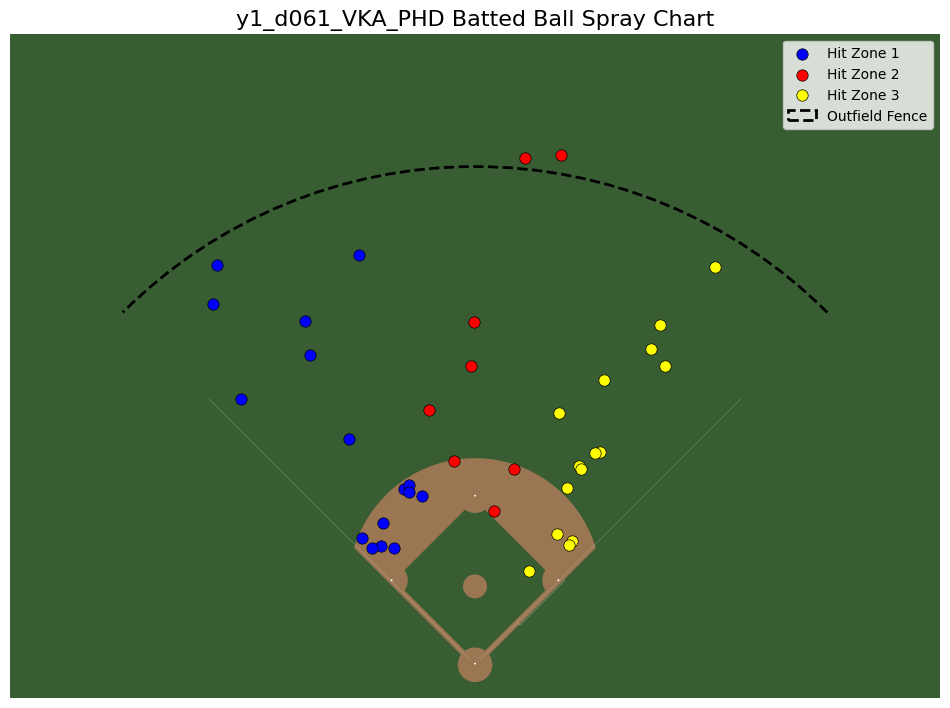

In [60]:
# Generating sample minor league field
sample_field = MiLBField()
fig, ax = plt.subplots(figsize=(12, 12))
sample_field.draw(ax=ax, display_range='full')

# Adding outfield grass
ax.add_patch(Rectangle(
    xy=(-500, -50),
    width=900,
    height=900,
    facecolor="#395d33",
))

# Filtering the dataframe in order to visualize the 3 different hit zones
zone_one = main_df[main_df['hit_zone'] == '1']
zone_two = main_df[main_df['hit_zone'] == '2']
zone_three = main_df[main_df['hit_zone'] == '3']

# Visualizing sample player's batted balls
ax.scatter(zone_one['ball_position_x'], zone_one['ball_position_y'], color='blue', 
        edgecolor='black', linewidth = 0.5, s=67, zorder=15, label='Hit Zone 1')


ax.scatter(zone_two['ball_position_x'], zone_two['ball_position_y'], color='red', 
        edgecolor='black', linewidth = 0.5, s=67, zorder=15, label='Hit Zone 2')


ax.scatter(zone_three['ball_position_x'], zone_three['ball_position_y'], color='yellow', 
        edgecolor='black', linewidth = 0.5, s=67, zorder=15, label='Hit Zone 3')


# Adding imaginary outfield fence with 375 foot dimensions, 
# not exactly real life accurate but works for this verification
fence = Arc((0, 0), width=750, height=750, angle=0, theta1=45, theta2=135,
            color='black', linewidth=2, linestyle = '--', zorder=10, label = 'Outfield Fence')
ax.add_patch(fence)

# Title of chart
ax.set_title(f'{main_df['game_string'][0]} Batted Ball Spray Chart', fontsize=16)
ax.set_aspect('equal')

ax.set_xlim(-350, 350)
ax.set_ylim(-25, 475)
ax.legend()
plt.show()

### Now that generating a good main dataframe to use for visualizing the hit zones later worked on small sample of one game, I want to try to conduct the same process on the data from all the games to make filtering the hit zone data by batter easier later on.

In [61]:
be_all_games_pandas.head()

,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
0,y1_d143_ADQ_ANI,1.0,50804.0,1,1,ANI,ADQ,y1,d143
1,y1_d143_ADQ_ANI,1.0,51254.0,2,2,ANI,ADQ,y1,d143
2,y1_d143_ADQ_ANI,1.0,51254.0,0,5,ANI,ADQ,y1,d143
3,y1_d143_ADQ_ANI,2.0,68204.0,1,1,ANI,ADQ,y1,d143
4,y1_d143_ADQ_ANI,2.0,68654.0,2,2,ANI,ADQ,y1,d143


In [62]:
be_all_games_pandas.shape

(286000, 9)

In [63]:
# Checking missing values
be_all_games_pandas.isna().sum()

game_string          0
play_per_game     2253
timestamp         2253
player_id            0
ball_eventcode       0
home_team            0
away_team            0
year                 0
day                  0
dtype: int64

In [64]:
# Dropping rows with missing values because it would be hard to infer the play_per_game and timestamp columns exactly from the other column data
# This results in 2253 rows being dropped, only about 0.008% of dataset
be_all_games_pandas_cleaned = be_all_games_pandas.dropna()

In [65]:
# Converting play_per_game and timestamp columns from floats (decimals) to ints (whole integers)
be_all_games_pandas_cleaned['play_per_game'] = be_all_games_pandas_cleaned['play_per_game'].astype(int)
be_all_games_pandas_cleaned['timestamp'] = be_all_games_pandas_cleaned['timestamp'].astype(int)
be_all_games_pandas_cleaned

,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
0,y1_d143_ADQ_ANI,1,50804,1,1,ANI,ADQ,y1,d143
1,y1_d143_ADQ_ANI,1,51254,2,2,ANI,ADQ,y1,d143
2,y1_d143_ADQ_ANI,1,51254,0,5,ANI,ADQ,y1,d143
3,y1_d143_ADQ_ANI,2,68204,1,1,ANI,ADQ,y1,d143
4,y1_d143_ADQ_ANI,2,68654,2,2,ANI,ADQ,y1,d143
...,...,...,...,...,...,...,...,...,...
285995,y1_d103_WTH_VAS,306,10161785,255,16,VAS,WTH,y1,d103
285996,y1_d103_WTH_VAS,306,10162185,4,2,VAS,WTH,y1,d103
285997,y1_d103_WTH_VAS,306,10162835,4,3,VAS,WTH,y1,d103
285998,y1_d103_WTH_VAS,306,10163985,3,2,VAS,WTH,y1,d103


In [66]:
# Converting dataframe to a Polars dataframe for ease of filtering later
be_all_games_polars_cleaned = pl.from_pandas(be_all_games_pandas_cleaned)
be_all_games_polars_cleaned

game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
str,i64,i64,i64,i64,str,str,str,str
"""y1_d143_ADQ_ANI""",1,50804,1,1,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,51254,2,2,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,51254,0,5,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",2,68204,1,1,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",2,68654,2,2,"""ANI""","""ADQ""","""y1""","""d143"""
…,…,…,…,…,…,…,…,…
"""y1_d103_WTH_VAS""",306,10161785,255,16,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306,10162185,4,2,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306,10162835,4,3,"""VAS""","""WTH""","""y1""","""d103"""


In [67]:
# Removing ball events with no player involved (just the ball bouncing on the field)
# Will use this in next steps when filtering for certain ball events
be_no_bounce_cleaned = be_all_games_pandas_cleaned.drop(be_all_games_pandas_cleaned[be_all_games_pandas_cleaned['player_id'] == 255].index)
be_no_bounce_cleaned.shape

(256739, 9)

In [68]:
# Converting dataframe to Polars for ease of filtering in next steps
be_no_bounce_cleaned_polars = pl.from_pandas(be_no_bounce_cleaned)
be_no_bounce_cleaned_polars

game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
str,i64,i64,i64,i64,str,str,str,str
"""y1_d143_ADQ_ANI""",1,50804,1,1,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,51254,2,2,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,51254,0,5,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",2,68204,1,1,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",2,68654,2,2,"""ANI""","""ADQ""","""y1""","""d143"""
…,…,…,…,…,…,…,…,…
"""y1_d103_WTH_VAS""",306,10159785,10,4,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306,10162185,4,2,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306,10162835,4,3,"""VAS""","""WTH""","""y1""","""d103"""


### Filtering the cleaned dataframe to generate a second dataframe that keeps only plays where the ball was acquired by a fielder (ball_eventcode == 2) after being hit (ball_eventcode == 4)

In [69]:
# Edited code snippet from Tutorial 7
# Filtering the data so that we only have plays where ball was acquired after being hit
balls_acquired_polars = be_no_bounce_cleaned_polars \
                               .filter( # Looking for a batter hitting the ball where the next row is the ball being acquired
                                      ((pl.col("ball_eventcode") == 2)).over(["game_string", "play_per_game"]) &
                                      (pl.col("ball_eventcode").shift(1) == 4).over(["game_string", "play_per_game"])            
                                      ) \
                               .select(
                                   ["game_string", "play_per_game",
                                      pl.col("timestamp").alias("hit_timestamp"),
                                    "player_id", "ball_eventcode"
                                      ]
                               )

balls_acquired_polars

game_string,play_per_game,hit_timestamp,player_id,ball_eventcode
str,i64,i64,i64,i64
"""y1_d143_ADQ_ANI""",17,382204,7,2
"""y1_d143_ADQ_ANI""",19,446804,9,2
"""y1_d143_ADQ_ANI""",22,659804,8,2
"""y1_d143_ADQ_ANI""",26,785204,5,2
"""y1_d143_ADQ_ANI""",29,896404,8,2
…,…,…,…,…
"""y1_d103_WTH_VAS""",290,9546835,9,2
"""y1_d103_WTH_VAS""",298,9776785,8,2
"""y1_d103_WTH_VAS""",301,9867135,9,2


In [70]:
# Again saving a Pandas dataframe version for use when merging a few of these tables later
balls_acquired_pandas = balls_acquired_polars.to_pandas()
balls_acquired_pandas.shape

(11082, 5)

### Now filtering cleaned dataframe in order to find batted balls that were homeruns (ball eventcode == 11)

In [71]:
# Generating new dataframe with only rows that are homeruns
be_hrs_polars = be_all_games_polars_cleaned \
                                  .filter( # Looking for a battted ball that is a homerun
                                      ((pl.col("ball_eventcode") == 11)).over(["game_string", "play_per_game"]) &
                                      (pl.col("ball_eventcode").shift(1) == 4).over(["game_string", "play_per_game"])
                                  ) \
                                  .select(
                                      ["game_string", "play_per_game",
                                      pl.col("timestamp").alias("hit_timestamp"),
                                      "player_id", "ball_eventcode"
                                      ]
                                      )
be_hrs_polars

game_string,play_per_game,hit_timestamp,player_id,ball_eventcode
str,i64,i64,i64,i64
"""y1_d144_ADQ_ANI""",112,4007288,255,11
"""y1_d144_ADQ_ANI""",213,7869388,255,11
"""y1_d144_ADQ_ANI""",281,10403538,255,11
"""y1_d145_ADQ_ANI""",142,5103521,255,11
"""y1_d145_ADQ_ANI""",209,7722471,255,11
…,…,…,…,…
"""y1_d131_WDF_VAS""",158,5208707,255,11
"""y1_d102_WTH_VAS""",32,1065952,255,11
"""y1_d102_WTH_VAS""",123,3948677,255,11


In [72]:
# Again saving a Pandas dataframe version for use when merging these tables later
be_hrs_pandas = be_hrs_polars.to_pandas()
be_hrs_pandas.shape

(650, 5)

### Now combining the rows from the 2 filtered dataframes to get the points at which the ball was acquired and all homeruns
- I figured that the point at which the ball is eventually acquired by a fielder in play is a good point for deciding which part of the field the ball was hit in, especially when only working with 3 large zones (left, center, and right)

In [73]:
# Combining the two dataframes, as explained above
valid_ball_events_pandas = pd.concat([balls_acquired_pandas, be_hrs_pandas], ignore_index=True)
valid_ball_events_pandas = valid_ball_events_pandas.sort_values(by='play_per_game')
valid_ball_events_pandas = valid_ball_events_pandas.rename(columns={'hit_timestamp': 'timestamp'})
valid_ball_events_pandas

,game_string,play_per_game,timestamp,player_id,ball_eventcode
9537,y1_d104_MSN_VAS,0,960204,6,2
9320,y1_d143_KVN_VAS,1,47016,8,2
6797,y1_d108_SPL_PHD,1,81069,7,2
10878,y1_d130_WDF_VAS,1,41089,3,2
6978,y1_d182_TQS_PHD,1,20938,7,2
...,...,...,...,...,...
8009,y1_d112_XGM_PHD,430,14493176,9,2
8010,y1_d112_XGM_PHD,432,14559326,9,2
8011,y1_d112_XGM_PHD,434,14708276,3,2
8012,y1_d112_XGM_PHD,437,14905976,5,2


In [74]:
# Saving a Polars dataframe version for use when merging tables later
valid_ball_events_polars = pl.from_pandas(valid_ball_events_pandas)
valid_ball_events_polars.shape

(11732, 5)

In [75]:
bp_all_games_polars

game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
str,i64,i64,f64,f64,f64,str,str,str,str
"""y1_d143_ADQ_ANI""",1,50804,-1.800237,56.6694,6.24252,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,50854,-1.503474,49.8654,6.12183,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,50904,-1.229208,43.1406,5.93865,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,50954,-0.977445,36.4956,5.69295,"""ANI""","""ADQ""","""y1""","""d143"""
"""y1_d143_ADQ_ANI""",1,51004,-0.748176,29.92956,5.3847,"""ANI""","""ADQ""","""y1""","""d143"""
…,…,…,…,…,…,…,…,…,…
"""y1_d103_WTH_VAS""",306,10163785,50.4192,81.4872,4.96017,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306,10163835,53.0214,77.9817,4.2378,"""VAS""","""WTH""","""y1""","""d103"""
"""y1_d103_WTH_VAS""",306,10163885,55.5744,74.4822,3.43224,"""VAS""","""WTH""","""y1""","""d103"""


In [76]:
# Dropping columns that are unnecessary for merging
bp_all_games_polars_cleaned = bp_all_games_polars.drop(['home_team', 'away_team', 'year', 'day', 'ball_position_z'])
bp_all_games_polars_cleaned

game_string,play_per_game,timestamp,ball_position_x,ball_position_y
str,i64,i64,f64,f64
"""y1_d143_ADQ_ANI""",1,50804,-1.800237,56.6694
"""y1_d143_ADQ_ANI""",1,50854,-1.503474,49.8654
"""y1_d143_ADQ_ANI""",1,50904,-1.229208,43.1406
"""y1_d143_ADQ_ANI""",1,50954,-0.977445,36.4956
"""y1_d143_ADQ_ANI""",1,51004,-0.748176,29.92956
…,…,…,…,…
"""y1_d103_WTH_VAS""",306,10163785,50.4192,81.4872
"""y1_d103_WTH_VAS""",306,10163835,53.0214,77.9817
"""y1_d103_WTH_VAS""",306,10163885,55.5744,74.4822


In [77]:
lineups_all_games_polars

game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,first_baseman,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b
str,i64,str,str,str,i64,i64,bool,str,str,str,str,str,str,str,str,str,str,str,str,str
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",1,1,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-5565""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",1,2,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-5565""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",2,3,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-7844""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",3,4,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-7206""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""","""PHD""","""VKA""",3,5,false,"""PHD-4341""","""PHD-5504""","""PHD-4573""","""PHD-7743""","""PHD-6069""","""PHD-0812""","""PHD-7166""","""PHD-8619""","""PHD-5994""","""VKA-7206""","""NA""","""NA""","""NA"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""y1_d217_VAS_ARN""",9,"""Bottom""","""ARN""","""VAS""",86,347,false,"""VAS-7895""","""VAS-2605""","""VAS-3928""","""VAS-4206""","""VAS-7896""","""VAS-1599""","""VAS-0984""","""VAS-4675""","""VAS-7926""","""ARN-3382""","""ARN-8020""","""NA""","""NA"""
"""y1_d217_VAS_ARN""",9,"""Bottom""","""ARN""","""VAS""",86,348,false,"""VAS-7895""","""VAS-2605""","""VAS-3928""","""VAS-4206""","""VAS-7896""","""VAS-1599""","""VAS-0984""","""VAS-4675""","""VAS-7926""","""ARN-3382""","""ARN-8020""","""NA""","""NA"""
"""y1_d217_VAS_ARN""",9,"""Bottom""","""ARN""","""VAS""",87,349,false,"""VAS-7895""","""VAS-2605""","""VAS-3928""","""VAS-4206""","""VAS-7896""","""VAS-1599""","""VAS-0984""","""VAS-4675""","""VAS-7926""","""ARN-9927""","""ARN-8020""","""NA""","""NA"""


In [78]:
# Dropping columns that are unnecessary for merging
lineups_all_games_polars_cleaned = lineups_all_games_polars.drop(['home_team', 'away_team', 'at_bat', 'is_pickoff', 'catcher', 
                                                                  'first_baseman', 'second_baseman', 'third_baseman', 
                                                                  'shortstop', 'left_fielder', 'center_fielder', 'right_fielder'])
lineups_all_games_polars_cleaned

game_string,inning,half_inning,play_per_game,pitcher,batter,on_1b,on_2b,on_3b
str,i64,str,i64,str,str,str,str,str
"""y1_d061_VKA_PHD""",1,"""Top""",1,"""PHD-4341""","""VKA-5565""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""",2,"""PHD-4341""","""VKA-5565""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""",3,"""PHD-4341""","""VKA-7844""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""",4,"""PHD-4341""","""VKA-7206""","""NA""","""NA""","""NA"""
"""y1_d061_VKA_PHD""",1,"""Top""",5,"""PHD-4341""","""VKA-7206""","""NA""","""NA""","""NA"""
…,…,…,…,…,…,…,…,…
"""y1_d217_VAS_ARN""",9,"""Bottom""",347,"""VAS-7895""","""ARN-3382""","""ARN-8020""","""NA""","""NA"""
"""y1_d217_VAS_ARN""",9,"""Bottom""",348,"""VAS-7895""","""ARN-3382""","""ARN-8020""","""NA""","""NA"""
"""y1_d217_VAS_ARN""",9,"""Bottom""",349,"""VAS-7895""","""ARN-9927""","""ARN-8020""","""NA""","""NA"""


### I realized after merging that the resulting dataframe below (which shows up after running the code block) is just uncomfortably large to work with (over 523 million rows), so I figured it would be better to create a function that works with smaller filtered dataframes based on the inputted batter id and from there generates the proper main dataframe for that individual batter.

In [79]:
# # Recreating step from earlier where I merged the filtered ball positions dataframe with the lineups dataframe
# # Doing it this time with the unfiltered dataframes and using the Polars dataframes for efficiency
# bp_w_lineups_polars = bp_all_games_polars_cleaned.join(lineups_all_games_polars_cleaned, on='play_per_game', how='left')
# bp_w_lineups_polars

# Function Creation
- ### Creating function that generates the zone of the field (left, center, right corresponding to 1, 2, and 3, respectively) where the batted ball was hit for the given batter/situation. Essentially, this is the hit zone generating function.

### First I will try to generate the desired final dataframe manually, step-by-step, to see if the function-generated dataframe will match up with the manual one generated below.

In [80]:
# Filtering the complete lineups dataframe to only lineups that include the given batter
demo = lineups_all_games_pandas[lineups_all_games_pandas['batter'] == 'VKA-5565']
demo.shape

(78, 21)

In [81]:
demo.head()

,game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,...,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,1,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
1,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,2,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
58,y1_d061_VKA_PHD,3,Top,PHD,VKA,18,59,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
59,y1_d061_VKA_PHD,3,Top,PHD,VKA,18,60,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA
60,y1_d061_VKA_PHD,3,Top,PHD,VKA,18,61,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NA,NA,NA


In [82]:
# Dropping rows with null values, only a small amount of the dataset, much less than 1%, as mentioned earlier in the notebook
bp_all_games_pandas_demo = bp_all_games_pandas.dropna()
bp_all_games_pandas_demo

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
0,y1_d143_ADQ_ANI,1.0,50804.0,-1.800237,56.66940,6.242520,ANI,ADQ,y1,d143
1,y1_d143_ADQ_ANI,1.0,50854.0,-1.503474,49.86540,6.121830,ANI,ADQ,y1,d143
2,y1_d143_ADQ_ANI,1.0,50904.0,-1.229208,43.14060,5.938650,ANI,ADQ,y1,d143
3,y1_d143_ADQ_ANI,1.0,50954.0,-0.977445,36.49560,5.692950,ANI,ADQ,y1,d143
4,y1_d143_ADQ_ANI,1.0,51004.0,-0.748176,29.92956,5.384700,ANI,ADQ,y1,d143
...,...,...,...,...,...,...,...,...,...,...
2280499,y1_d103_WTH_VAS,306.0,10163785.0,50.419200,81.48720,4.960170,VAS,WTH,y1,d103
2280500,y1_d103_WTH_VAS,306.0,10163835.0,53.021400,77.98170,4.237800,VAS,WTH,y1,d103
2280501,y1_d103_WTH_VAS,306.0,10163885.0,55.574400,74.48220,3.432240,VAS,WTH,y1,d103
2280502,y1_d103_WTH_VAS,306.0,10163935.0,58.078200,70.98930,2.543556,VAS,WTH,y1,d103


In [83]:
# Filtering complete ball positions dataframe down to only games that the batter hit in
bp_all_games_demo = bp_all_games_pandas_demo[bp_all_games_pandas_demo['game_string'].isin(demo['game_string'])]
bp_all_games_demo

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
1617105,y1_d061_VKA_PHD,1.0,63614.0,-2.139183,53.55480,5.80299,PHD,VKA,y1,d061
1617106,y1_d061_VKA_PHD,1.0,63664.0,-1.663587,46.78290,5.50713,PHD,VKA,y1,d061
1617107,y1_d061_VKA_PHD,1.0,63714.0,-1.200690,40.07640,5.16087,PHD,VKA,y1,d061
1617108,y1_d061_VKA_PHD,1.0,63764.0,-0.750492,33.43440,4.76424,PHD,VKA,y1,d061
1617109,y1_d061_VKA_PHD,1.0,63814.0,-0.312996,26.85777,4.31727,PHD,VKA,y1,d061
...,...,...,...,...,...,...,...,...,...,...
1649339,y1_d064_VKA_PHD,299.0,9822365.0,-127.054500,152.68560,13.96746,PHD,VKA,y1,d064
1649340,y1_d064_VKA_PHD,299.0,9822398.0,-127.912200,153.57270,11.99661,PHD,VKA,y1,d064
1649341,y1_d064_VKA_PHD,299.0,9822431.0,-128.769600,154.46850,10.00737,PHD,VKA,y1,d064
1649342,y1_d064_VKA_PHD,299.0,9822464.0,-129.627000,155.37330,7.99992,PHD,VKA,y1,d064


In [84]:
# Converting the play_per_game and timestamp columns from floats (decimals) to ints (integers)
bp_all_games_demo['play_per_game'] = bp_all_games_demo['play_per_game'].astype(int)
bp_all_games_demo['timestamp'] = bp_all_games_demo['timestamp'].astype(int)
bp_all_games_demo.head()

,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
1617105,y1_d061_VKA_PHD,1,63614,-2.139183,53.55480,5.80299,PHD,VKA,y1,d061
1617106,y1_d061_VKA_PHD,1,63664,-1.663587,46.78290,5.50713,PHD,VKA,y1,d061
1617107,y1_d061_VKA_PHD,1,63714,-1.200690,40.07640,5.16087,PHD,VKA,y1,d061
1617108,y1_d061_VKA_PHD,1,63764,-0.750492,33.43440,4.76424,PHD,VKA,y1,d061
1617109,y1_d061_VKA_PHD,1,63814,-0.312996,26.85777,4.31727,PHD,VKA,y1,d061


In [85]:
valid_ball_events_demo = valid_ball_events_pandas.copy()
valid_ball_events_demo

,game_string,play_per_game,timestamp,player_id,ball_eventcode
9537,y1_d104_MSN_VAS,0,960204,6,2
9320,y1_d143_KVN_VAS,1,47016,8,2
6797,y1_d108_SPL_PHD,1,81069,7,2
10878,y1_d130_WDF_VAS,1,41089,3,2
6978,y1_d182_TQS_PHD,1,20938,7,2
...,...,...,...,...,...
8009,y1_d112_XGM_PHD,430,14493176,9,2
8010,y1_d112_XGM_PHD,432,14559326,9,2
8011,y1_d112_XGM_PHD,434,14708276,3,2
8012,y1_d112_XGM_PHD,437,14905976,5,2


In [86]:
# Merging the complete valid ball events dataframe with the games the batter hit in
# This will provide a dataframe that includes all the hitter's valid batted balls with the ball positions included
be_bp_demo = valid_ball_events_demo.merge(bp_all_games_demo, on='timestamp', how='inner')
be_bp_demo

,game_string_x,play_per_game_x,timestamp,player_id,ball_eventcode,game_string_y,play_per_game_y,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
0,y1_d061_VKA_PHD,2,78414,4,2,y1_d061_VKA_PHD,2,29.325990,147.6795,4.234620,PHD,VKA,y1,d061
1,y1_d061_VKA_PHD,3,112164,4,2,y1_d061_VKA_PHD,3,78.284400,149.4936,0.951447,PHD,VKA,y1,d061
2,y1_d062_VKA_PHD,3,94884,3,2,y1_d062_VKA_PHD,3,85.211100,89.1090,4.419930,PHD,VKA,y1,d062
3,y1_d063_VKA_PHD,4,50165,6,2,y1_d063_VKA_PHD,4,0.270456,116.6358,3.100680,PHD,VKA,y1,d063
4,y1_d064_VKA_PHD,8,225131,8,2,y1_d064_VKA_PHD,8,-32.589000,279.7374,0.000000,PHD,VKA,y1,d064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,y1_d062_VKA_PHD,291,9396984,3,2,y1_d062_VKA_PHD,291,68.678100,102.7209,1.873011,PHD,VKA,y1,d062
190,y1_d062_VKA_PHD,293,9453634,4,2,y1_d062_VKA_PHD,293,58.287900,126.9195,2.937405,PHD,VKA,y1,d062
191,y1_d064_VKA_PHD,293,9656507,5,2,y1_d064_VKA_PHD,293,-113.823900,65.1213,7.403370,PHD,VKA,y1,d064
192,y1_d062_VKA_PHD,296,9545584,3,2,y1_d062_VKA_PHD,296,71.758800,101.0460,5.585310,PHD,VKA,y1,d062


In [87]:
# Removing unnecessary columns and renaming some columns
be_bp_demo_cleaned = be_bp_demo.drop(
                        columns=['game_string_y', 'home_team', 'away_team', 
                                 'year', 'day', 'play_per_game_y']).rename(
                        columns={'game_string_x': 'game_string',
                                 'play_per_game_x': 'play_per_game'})
be_bp_demo_cleaned.head()

,game_string,play_per_game,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z
0,y1_d061_VKA_PHD,2,78414,4,2,29.325990,147.6795,4.234620
1,y1_d061_VKA_PHD,3,112164,4,2,78.284400,149.4936,0.951447
2,y1_d062_VKA_PHD,3,94884,3,2,85.211100,89.1090,4.419930
3,y1_d063_VKA_PHD,4,50165,6,2,0.270456,116.6358,3.100680
4,y1_d064_VKA_PHD,8,225131,8,2,-32.589000,279.7374,0.000000


In [88]:
# Merging the lineup info from games the batter hit in with the valid ball position dataframe from above
# Have to merge on two keys here, instead of just one, because there could be multiple identical game_strings or play_per_games within the dataframe
# Using both as keys ensures each play is preserved within its own game
be_bp_w_batter_demo = demo.merge(be_bp_demo_cleaned, on=['game_string', 'play_per_game'], how='inner')
be_bp_w_batter_demo.shape

(12, 27)

In [89]:
be_bp_w_batter_demo.head()

,game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,...,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z
0,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,2,False,PHD-4341,PHD-5504,...,VKA-5565,NA,NA,NA,78414,4,2,29.32599,147.6795,4.234620
1,y1_d061_VKA_PHD,3,Top,PHD,VKA,18,62,False,PHD-4341,PHD-5504,...,VKA-5565,NA,NA,NA,1878764,4,2,69.32220,132.8166,0.000000
2,y1_d062_VKA_PHD,1,Top,PHD,VKA,1,3,False,PHD-8650,PHD-5504,...,VKA-5565,NA,NA,NA,94884,3,2,85.21110,89.1090,4.419930
3,y1_d062_VKA_PHD,6,Top,PHD,VKA,45,199,False,PHD-1278,PHD-5504,...,VKA-5565,VKA-2967,NA,VKA-3145,5872084,4,2,30.56100,124.6287,1.589652
4,y1_d062_VKA_PHD,9,Top,PHD,VKA,68,293,False,PHD-4376,PHD-5504,...,VKA-5565,NA,NA,NA,9453634,4,2,58.28790,126.9195,2.937405


In [90]:
be_bp_w_batter_demo.columns

Index(['game_string', 'inning', 'half_inning', 'home_team', 'away_team',
       'at_bat', 'play_per_game', 'is_pickoff', 'pitcher', 'catcher',
       'first_baseman', 'second_baseman', 'third_baseman', 'shortstop',
       'left_fielder', 'center_fielder', 'right_fielder', 'batter', 'on_1b',
       'on_2b', 'on_3b', 'timestamp', 'player_id', 'ball_eventcode',
       'ball_position_x', 'ball_position_y', 'ball_position_z'],
      dtype='str')

In [91]:
# Removing unnecessary columns
be_bp_w_batter_demo_cleaned = be_bp_w_batter_demo.drop(
                        columns=['home_team', 'away_team', 'is_pickoff', 'catcher', 
                                 'first_baseman', 'second_baseman', 'third_baseman', 'shortstop',
                                 'left_fielder', 'center_fielder', 'right_fielder'])
be_bp_w_batter_demo_cleaned.head()

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z
0,y1_d061_VKA_PHD,1,Top,1,2,PHD-4341,VKA-5565,NA,NA,NA,78414,4,2,29.32599,147.6795,4.234620
1,y1_d061_VKA_PHD,3,Top,18,62,PHD-4341,VKA-5565,NA,NA,NA,1878764,4,2,69.32220,132.8166,0.000000
2,y1_d062_VKA_PHD,1,Top,1,3,PHD-8650,VKA-5565,NA,NA,NA,94884,3,2,85.21110,89.1090,4.419930
3,y1_d062_VKA_PHD,6,Top,45,199,PHD-1278,VKA-5565,VKA-2967,NA,VKA-3145,5872084,4,2,30.56100,124.6287,1.589652
4,y1_d062_VKA_PHD,9,Top,68,293,PHD-4376,VKA-5565,NA,NA,NA,9453634,4,2,58.28790,126.9195,2.937405


In [92]:
final_demo_df = be_bp_w_batter_demo_cleaned.copy()

# Labeling the field zones for filtering the batted balls (3 corresponds to right field, 2 to center field, and 1 to left field)
field_zones = ['3', '2', '1']

# Defining the angle cutoffs for each zone, essentially differentiating between left, center, and right field
degree_zones = [45.0, 75.0, 105.0, 135.0]

# Calculating the hit angles and adding that resulting data as an additional column
final_demo_df['hit_angles'] = np.degrees(np.arctan2(final_demo_df['ball_position_y'], final_demo_df['ball_position_x']))

# Adding a column corresponding to the zone in which the batted ball was hit (I'm calling it the stroke zone for now)
final_demo_df['hit_zone'] = pd.cut(final_demo_df['hit_angles'], bins = degree_zones,
                                        labels = field_zones, include_lowest=True)

# Essentially removing foul balls here (balls to the left of 3rd base line or to the right of 1st base line)
final_batter_df = final_demo_df.dropna()
final_batter_df

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone
0,y1_d061_VKA_PHD,1,Top,1,2,PHD-4341,VKA-5565,NA,NA,NA,78414,4,2,29.325990,147.6795,4.234620,78.768396,2
1,y1_d061_VKA_PHD,3,Top,18,62,PHD-4341,VKA-5565,NA,NA,NA,1878764,4,2,69.322200,132.8166,0.000000,62.438175,3
2,y1_d062_VKA_PHD,1,Top,1,3,PHD-8650,VKA-5565,NA,NA,NA,94884,3,2,85.211100,89.1090,4.419930,46.280954,3
3,y1_d062_VKA_PHD,6,Top,45,199,PHD-1278,VKA-5565,VKA-2967,NA,VKA-3145,5872084,4,2,30.561000,124.6287,1.589652,76.222004,2
4,y1_d062_VKA_PHD,9,Top,68,293,PHD-4376,VKA-5565,NA,NA,NA,9453634,4,2,58.287900,126.9195,2.937405,65.333002,3
5,y1_d063_VKA_PHD,1,Top,1,4,PHD-7005,VKA-5565,NA,NA,NA,50165,6,2,0.270456,116.6358,3.100680,89.867142,2
6,y1_d063_VKA_PHD,4,Top,27,93,PHD-7005,VKA-5565,NA,NA,NA,2949815,6,2,-32.400600,141.6720,0.000000,102.882084,2
7,y1_d063_VKA_PHD,6,Top,46,160,PHD-5815,VKA-5565,VKA-2967,NA,NA,5261615,8,2,11.883360,327.3090,5.624070,87.920719,2
8,y1_d064_VKA_PHD,2,Top,16,74,PHD-6227,VKA-5565,VKA-1252,NA,NA,2132103,8,2,-13.078980,234.1587,5.412870,93.196945,2
9,y1_d064_VKA_PHD,5,Top,39,162,PHD-0342,VKA-5565,NA,NA,NA,5217178,7,2,-173.409600,274.3833,5.355690,122.292790,1


In [93]:
# Replacing the existing runners on base columns with T/F indicators showing whether or not a runner is on each base during the batter ball
final_batter_df['on_1b'] = final_batter_df['on_1b'] != 'NA'
final_batter_df['on_2b'] = final_batter_df['on_2b'] != 'NA'
final_batter_df['on_3b'] = final_batter_df['on_3b'] != 'NA'
final_batter_df

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone
0,y1_d061_VKA_PHD,1,Top,1,2,PHD-4341,VKA-5565,False,False,False,78414,4,2,29.325990,147.6795,4.234620,78.768396,2
1,y1_d061_VKA_PHD,3,Top,18,62,PHD-4341,VKA-5565,False,False,False,1878764,4,2,69.322200,132.8166,0.000000,62.438175,3
2,y1_d062_VKA_PHD,1,Top,1,3,PHD-8650,VKA-5565,False,False,False,94884,3,2,85.211100,89.1090,4.419930,46.280954,3
3,y1_d062_VKA_PHD,6,Top,45,199,PHD-1278,VKA-5565,True,False,True,5872084,4,2,30.561000,124.6287,1.589652,76.222004,2
4,y1_d062_VKA_PHD,9,Top,68,293,PHD-4376,VKA-5565,False,False,False,9453634,4,2,58.287900,126.9195,2.937405,65.333002,3
5,y1_d063_VKA_PHD,1,Top,1,4,PHD-7005,VKA-5565,False,False,False,50165,6,2,0.270456,116.6358,3.100680,89.867142,2
6,y1_d063_VKA_PHD,4,Top,27,93,PHD-7005,VKA-5565,False,False,False,2949815,6,2,-32.400600,141.6720,0.000000,102.882084,2
7,y1_d063_VKA_PHD,6,Top,46,160,PHD-5815,VKA-5565,True,False,False,5261615,8,2,11.883360,327.3090,5.624070,87.920719,2
8,y1_d064_VKA_PHD,2,Top,16,74,PHD-6227,VKA-5565,True,False,False,2132103,8,2,-13.078980,234.1587,5.412870,93.196945,2
9,y1_d064_VKA_PHD,5,Top,39,162,PHD-0342,VKA-5565,False,False,False,5217178,7,2,-173.409600,274.3833,5.355690,122.292790,1


In [94]:
# Adding a new column that represents the total number of runners on base during each batted ball
final_batter_df['ROB'] = final_batter_df[['on_1b', 'on_2b', 'on_3b']].eq(True).sum(axis=1)
final_batter_df

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB
0,y1_d061_VKA_PHD,1,Top,1,2,PHD-4341,VKA-5565,False,False,False,78414,4,2,29.325990,147.6795,4.234620,78.768396,2,0
1,y1_d061_VKA_PHD,3,Top,18,62,PHD-4341,VKA-5565,False,False,False,1878764,4,2,69.322200,132.8166,0.000000,62.438175,3,0
2,y1_d062_VKA_PHD,1,Top,1,3,PHD-8650,VKA-5565,False,False,False,94884,3,2,85.211100,89.1090,4.419930,46.280954,3,0
3,y1_d062_VKA_PHD,6,Top,45,199,PHD-1278,VKA-5565,True,False,True,5872084,4,2,30.561000,124.6287,1.589652,76.222004,2,2
4,y1_d062_VKA_PHD,9,Top,68,293,PHD-4376,VKA-5565,False,False,False,9453634,4,2,58.287900,126.9195,2.937405,65.333002,3,0
5,y1_d063_VKA_PHD,1,Top,1,4,PHD-7005,VKA-5565,False,False,False,50165,6,2,0.270456,116.6358,3.100680,89.867142,2,0
6,y1_d063_VKA_PHD,4,Top,27,93,PHD-7005,VKA-5565,False,False,False,2949815,6,2,-32.400600,141.6720,0.000000,102.882084,2,0
7,y1_d063_VKA_PHD,6,Top,46,160,PHD-5815,VKA-5565,True,False,False,5261615,8,2,11.883360,327.3090,5.624070,87.920719,2,1
8,y1_d064_VKA_PHD,2,Top,16,74,PHD-6227,VKA-5565,True,False,False,2132103,8,2,-13.078980,234.1587,5.412870,93.196945,2,1
9,y1_d064_VKA_PHD,5,Top,39,162,PHD-0342,VKA-5565,False,False,False,5217178,7,2,-173.409600,274.3833,5.355690,122.292790,1,0


In [95]:
# Adding a new column that indicates whether or not a batted ball was a homerun
final_batter_df['is_homerun'] = final_batter_df['ball_eventcode'] == 11
final_batter_df

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
0,y1_d061_VKA_PHD,1,Top,1,2,PHD-4341,VKA-5565,False,False,False,78414,4,2,29.325990,147.6795,4.234620,78.768396,2,0,False
1,y1_d061_VKA_PHD,3,Top,18,62,PHD-4341,VKA-5565,False,False,False,1878764,4,2,69.322200,132.8166,0.000000,62.438175,3,0,False
2,y1_d062_VKA_PHD,1,Top,1,3,PHD-8650,VKA-5565,False,False,False,94884,3,2,85.211100,89.1090,4.419930,46.280954,3,0,False
3,y1_d062_VKA_PHD,6,Top,45,199,PHD-1278,VKA-5565,True,False,True,5872084,4,2,30.561000,124.6287,1.589652,76.222004,2,2,False
4,y1_d062_VKA_PHD,9,Top,68,293,PHD-4376,VKA-5565,False,False,False,9453634,4,2,58.287900,126.9195,2.937405,65.333002,3,0,False
5,y1_d063_VKA_PHD,1,Top,1,4,PHD-7005,VKA-5565,False,False,False,50165,6,2,0.270456,116.6358,3.100680,89.867142,2,0,False
6,y1_d063_VKA_PHD,4,Top,27,93,PHD-7005,VKA-5565,False,False,False,2949815,6,2,-32.400600,141.6720,0.000000,102.882084,2,0,False
7,y1_d063_VKA_PHD,6,Top,46,160,PHD-5815,VKA-5565,True,False,False,5261615,8,2,11.883360,327.3090,5.624070,87.920719,2,1,False
8,y1_d064_VKA_PHD,2,Top,16,74,PHD-6227,VKA-5565,True,False,False,2132103,8,2,-13.078980,234.1587,5.412870,93.196945,2,1,False
9,y1_d064_VKA_PHD,5,Top,39,162,PHD-0342,VKA-5565,False,False,False,5217178,7,2,-173.409600,274.3833,5.355690,122.292790,1,0,False


In [96]:
duplicates_demo = final_batter_df.duplicated().sum()
print(duplicates_demo)

0


### Main Function

In [97]:
def hit_zone_generator(batter):
    '''
    This function generates the zone of the field in which the ball was hit
    for each of  the given batter's batted balls.

    Parameters: batter (string) - the player id code of the batter
    '''

    # Checking to make sure that a proper batter ID is provided
    if batter == '':
        return 'Please provide Batter ID.'
    
    # Filtering the complete lineups dataframe to only lineups that include the given batter
    lineups_w_batter = lineups_all_games_pandas[lineups_all_games_pandas['batter'] == batter]

    # Dropping rows with null values, only a small amount of the dataset, much less than 1%, as mentioned earlier in the notebook
    bp_all_games_cleaned = bp_all_games_pandas.dropna()

    # Filtering complete ball positions dataframe down to only games that the batter hit in
    bp_batter_games = bp_all_games_cleaned[bp_all_games_cleaned['game_string'].isin(lineups_w_batter['game_string'])]

    # Converting the play_per_game and timestamp columns from floats (decimals) to ints (integers)
    bp_batter_games['play_per_game'] = bp_batter_games['play_per_game'].astype(int)
    bp_batter_games['timestamp'] = bp_batter_games['timestamp'].astype(int)

    valid_ball_events_batter = valid_ball_events_pandas.copy()

    # Merging the complete valid ball events dataframe (which was created earlier) with the games the batter hit in
    # This will provide a dataframe that includes all the hitter's valid batted balls with the ball positions included
    be_bp_batter = valid_ball_events_batter.merge(bp_batter_games, on='timestamp', how='inner')

    # Removing unnecessary columns and renaming some columns
    be_bp_batter_cleaned = be_bp_batter.drop(
                        columns=['game_string_y', 'home_team', 'away_team', 
                                 'year', 'day', 'play_per_game_y']).rename(
                        columns={'game_string_x': 'game_string',
                                 'play_per_game_x': 'play_per_game'})
    
    # Merging the lineup info from games the batter hit in with the valid ball position dataframe from above
    be_bp_w_batter = lineups_w_batter.merge(be_bp_batter_cleaned, on=['game_string', 'play_per_game'], how='inner')

    # Removing unnecessary columns
    be_bp_w_batter_demo_cleaned = be_bp_w_batter.drop(
                            columns=['home_team', 'away_team', 'is_pickoff', 'catcher', 
                                    'first_baseman', 'second_baseman', 'third_baseman', 'shortstop',
                                    'left_fielder', 'center_fielder', 'right_fielder'])
    
    final_batter_df = be_bp_w_batter_demo_cleaned.copy()

    # Labeling the field zones for filtering the batted balls (3 corresponds to right field, 2 to center field, and 1 to left field)
    field_zones = ['3', '2', '1']

    # Defining the angle cutoffs for each zone, essentially differentiating between left, center, and right field
    degree_zones = [45.0, 75.0, 105.0, 135.0]

    # Calculating the hit angles and adding that resulting data as an additional column
    final_batter_df['hit_angles'] = np.degrees(np.arctan2(final_batter_df['ball_position_y'], final_batter_df['ball_position_x']))

    # Adding a column corresponding to the zone in which the batted ball was hit
    final_batter_df['hit_zone'] = pd.cut(final_batter_df['hit_angles'], bins = degree_zones,
                                           labels = field_zones, include_lowest=True)
    
    # Essentially removing foul balls here (balls to the left of 3rd base line or to the right of 1st base line) and dropping duplicate rows if they exist
    final_batter_df = final_batter_df.dropna()
    final_batter_df = final_batter_df.drop_duplicates()

    # Replacing the existing runners on base columns with T/F indicators showing whether or not a runner is on each base during the batter ball
    final_batter_df['on_1b'] = final_batter_df['on_1b'] != 'NA'
    final_batter_df['on_2b'] = final_batter_df['on_2b'] != 'NA'
    final_batter_df['on_3b'] = final_batter_df['on_3b'] != 'NA'

    # Adding a new column that represents the total number of runners on base during each batted ball
    final_batter_df['ROB'] = final_batter_df[['on_1b', 'on_2b', 'on_3b']].eq(True).sum(axis=1)

    # Adding a new column that indicates whether or not a batted ball was a homerun
    final_batter_df['is_homerun'] = final_batter_df['ball_eventcode'] == 11
    
    return final_batter_df

In [98]:
test_player_one = hit_zone_generator('VKA-5565')
test_player_one

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
0,y1_d061_VKA_PHD,1,Top,1,2,PHD-4341,VKA-5565,False,False,False,78414,4,2,29.325990,147.6795,4.234620,78.768396,2,0,False
1,y1_d061_VKA_PHD,3,Top,18,62,PHD-4341,VKA-5565,False,False,False,1878764,4,2,69.322200,132.8166,0.000000,62.438175,3,0,False
2,y1_d062_VKA_PHD,1,Top,1,3,PHD-8650,VKA-5565,False,False,False,94884,3,2,85.211100,89.1090,4.419930,46.280954,3,0,False
3,y1_d062_VKA_PHD,6,Top,45,199,PHD-1278,VKA-5565,True,False,True,5872084,4,2,30.561000,124.6287,1.589652,76.222004,2,2,False
4,y1_d062_VKA_PHD,9,Top,68,293,PHD-4376,VKA-5565,False,False,False,9453634,4,2,58.287900,126.9195,2.937405,65.333002,3,0,False
5,y1_d063_VKA_PHD,1,Top,1,4,PHD-7005,VKA-5565,False,False,False,50165,6,2,0.270456,116.6358,3.100680,89.867142,2,0,False
6,y1_d063_VKA_PHD,4,Top,27,93,PHD-7005,VKA-5565,False,False,False,2949815,6,2,-32.400600,141.6720,0.000000,102.882084,2,0,False
7,y1_d063_VKA_PHD,6,Top,46,160,PHD-5815,VKA-5565,True,False,False,5261615,8,2,11.883360,327.3090,5.624070,87.920719,2,1,False
8,y1_d064_VKA_PHD,2,Top,16,74,PHD-6227,VKA-5565,True,False,False,2132103,8,2,-13.078980,234.1587,5.412870,93.196945,2,1,False
9,y1_d064_VKA_PHD,5,Top,39,162,PHD-0342,VKA-5565,False,False,False,5217178,7,2,-173.409600,274.3833,5.355690,122.292790,1,0,False


In [99]:
final_batter_df

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
0,y1_d061_VKA_PHD,1,Top,1,2,PHD-4341,VKA-5565,False,False,False,78414,4,2,29.325990,147.6795,4.234620,78.768396,2,0,False
1,y1_d061_VKA_PHD,3,Top,18,62,PHD-4341,VKA-5565,False,False,False,1878764,4,2,69.322200,132.8166,0.000000,62.438175,3,0,False
2,y1_d062_VKA_PHD,1,Top,1,3,PHD-8650,VKA-5565,False,False,False,94884,3,2,85.211100,89.1090,4.419930,46.280954,3,0,False
3,y1_d062_VKA_PHD,6,Top,45,199,PHD-1278,VKA-5565,True,False,True,5872084,4,2,30.561000,124.6287,1.589652,76.222004,2,2,False
4,y1_d062_VKA_PHD,9,Top,68,293,PHD-4376,VKA-5565,False,False,False,9453634,4,2,58.287900,126.9195,2.937405,65.333002,3,0,False
5,y1_d063_VKA_PHD,1,Top,1,4,PHD-7005,VKA-5565,False,False,False,50165,6,2,0.270456,116.6358,3.100680,89.867142,2,0,False
6,y1_d063_VKA_PHD,4,Top,27,93,PHD-7005,VKA-5565,False,False,False,2949815,6,2,-32.400600,141.6720,0.000000,102.882084,2,0,False
7,y1_d063_VKA_PHD,6,Top,46,160,PHD-5815,VKA-5565,True,False,False,5261615,8,2,11.883360,327.3090,5.624070,87.920719,2,1,False
8,y1_d064_VKA_PHD,2,Top,16,74,PHD-6227,VKA-5565,True,False,False,2132103,8,2,-13.078980,234.1587,5.412870,93.196945,2,1,False
9,y1_d064_VKA_PHD,5,Top,39,162,PHD-0342,VKA-5565,False,False,False,5217178,7,2,-173.409600,274.3833,5.355690,122.292790,1,0,False


### Dataframe from function matches dataframe generating above, which is a good sign that the function is returning the correct data.

In [100]:
is_identical = final_batter_df.equals(test_player_one)
is_identical

True

## Adding stroke zone dataframe filter function that allows for the player's batted ball events to be filtered with additional context.

In [101]:
print(final_batter_df.dtypes)

game_string             str
inning                int64
half_inning             str
at_bat                int64
play_per_game         int64
pitcher                 str
batter                  str
on_1b                  bool
on_2b                  bool
on_3b                  bool
timestamp             int64
player_id             int64
ball_eventcode        int64
ball_position_x     float64
ball_position_y     float64
ball_position_z     float64
hit_angles          float64
hit_zone           category
ROB                   int64
is_homerun             bool
dtype: object


In [102]:
def hit_zone_filter(batter, game = None, inning = None, pitcher = None, 
                       on_1b = None, on_2b = None, on_3b = None, runners_on = None, 
                       is_homerun = None, hit_zone = None):
    '''
    This function generates the zone of the field in which the ball was hit
    for each of the given batter's batted balls. It also takes in additional 
    optional context, such as game_string, inning, pitcher faced, etc.

    Required parameters:
    batter (string) - the player id code of the batter

    Optional parameters:
    game (string) - the game_string in which the batted ball occurred
    inning (int) - the inning in which the batted ball occurred
    pitcher (string) - the pitcher off which the batted ball was hit
    on_1b, on_2b, on_3b (boolean) - True or False values with each indicating whether or not a batter is on the given base
    runners_on (int) - the total numbers of runners on base during the batted ball
    hit_zone (category - input argument as string) - the region of the field in which the ball was hit
    is_homerun (boolean) - True or False value indicating whether or not the batted ball was a homerun
    '''

    # Checking to make sure that a proper batter ID is provided
    if batter == '':
        return 'Please provide Batter ID.'
    
    filtered_hit_zone = hit_zone_generator(batter)

    # The below if-else statements look like a lot, but they are all 
    # just checking to see if a value was provided for the specific parameter
    if game is not None:
        filtered_hit_zone = filtered_hit_zone[filtered_hit_zone['game_string'] == game]

    if inning is not None:
        filtered_hit_zone = filtered_hit_zone[filtered_hit_zone['inning'] == inning]

    if pitcher is not None:
        filtered_hit_zone = filtered_hit_zone[filtered_hit_zone['pitcher'] == pitcher]
    
    if on_1b is not None:
        filtered_hit_zone = filtered_hit_zone[filtered_hit_zone['on_1b'] == on_1b]
    
    if on_2b is not None:
        filtered_hit_zone = filtered_hit_zone[filtered_hit_zone['on_2b'] == on_2b]

    if on_3b is not None:
        filtered_hit_zone = filtered_hit_zone[filtered_hit_zone['on_3b'] == on_3b]
    
    if runners_on is not None:
        filtered_hit_zone = filtered_hit_zone[filtered_hit_zone['ROB'] == runners_on]
    
    if is_homerun is not None:
        filtered_hit_zone = filtered_hit_zone[filtered_hit_zone['is_homerun'] == is_homerun]
    
    if hit_zone is not None:
        filtered_hit_zone = filtered_hit_zone[filtered_hit_zone['hit_zone'] == hit_zone]
    
    # Returning filtered hit zone dataframe
    return filtered_hit_zone

In [103]:
hit_zone_filter(batter = 'ANI-2596', is_homerun = True)

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
0,y1_d067.5_NLG_ANI,1,Bottom,4,14,NLG-0832,ANI-2596,False,False,False,434631,255,11,-46.7388,442.8600,22.57218,96.024611,2,0,True
7,y1_d106_OER_ANI,5,Bottom,44,181,OER-0153,ANI-2596,True,False,False,5603487,255,11,244.5069,319.8030,11.08644,52.600108,3,1,True
10,y1_d107_OER_ANI,4,Bottom,32,141,OER-1774,ANI-2596,False,False,False,4127135,255,11,218.8029,285.5079,51.78210,52.534754,3,0,True
25,y1_d122_MSE_ANI,5,Bottom,47,198,MSE-2082,ANI-2596,False,False,False,6624838,255,11,262.1247,278.8935,15.00660,46.775308,3,0,True
33,y1_d138_QBR_ANI,1,Bottom,10,39,QBR-4345,ANI-2596,True,True,False,1269169,255,11,188.4696,309.2760,21.48873,58.642302,3,2,True
36,y1_d139_QBR_ANI,2,Bottom,17,74,QBR-7076,ANI-2596,False,False,False,2275374,255,11,-62.3709,448.9230,12.58719,97.909727,2,0,True
43,y1_d140_QBR_ANI,5,Bottom,50,203,QBR-2817,ANI-2596,False,False,False,7485113,255,11,240.0762,323.4270,51.76380,53.413919,3,0,True
47,y1_d141_QBR_ANI,9,Bottom,99,340,QBR-8428,ANI-2596,True,False,False,10208849,255,11,47.7747,457.4700,14.10651,84.038074,2,1,True
48,y1_d144_ADQ_ANI,4,Bottom,30,112,ADQ-6440,ANI-2596,False,False,False,4007288,255,11,-49.7940,427.9230,35.83350,96.637206,2,0,True
56,y1_d168_EMB_ANI,4,Bottom,38,157,EMB-3769,ANI-2596,True,False,False,5511379,255,11,128.6370,349.3890,16.75848,69.787453,3,1,True


# Testing/Verifying

### Testing on other players to see if table continues to make sense intuitively

In [104]:
test_player_two = hit_zone_generator('VKA-7206')
test_player_two

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
0,y1_d061_VKA_PHD,1,Top,3,8,PHD-4341,VKA-7206,False,False,False,220314,6,2,-34.9641,191.6787,4.106190,100.337663,2,0,False
1,y1_d061_VKA_PHD,9,Top,61,221,PHD-0342,VKA-7206,True,False,False,7502714,9,2,97.1970,214.5825,-0.866442,65.631439,3,1,False
2,y1_d062_VKA_PHD,4,Top,23,107,PHD-8650,VKA-7206,False,False,False,2987234,4,2,46.3059,153.1017,6.535410,73.171959,3,0,False
3,y1_d062_VKA_PHD,7,Top,52,227,PHD-1278,VKA-7206,False,False,False,6958184,7,2,-119.8587,251.0223,-0.533847,115.523649,1,0,False
4,y1_d063_VKA_PHD,1,Top,3,9,PHD-7005,VKA-7206,False,False,False,163215,3,2,78.4251,80.9181,5.123850,45.896347,3,0,False


In [105]:
num_duplicates = test_player_two.duplicated().sum()
num_duplicates

np.int64(0)

In [106]:
hit_zone_filter('VKA-7206', inning = 1)

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
0,y1_d061_VKA_PHD,1,Top,3,8,PHD-4341,VKA-7206,False,False,False,220314,6,2,-34.9641,191.6787,4.10619,100.337663,2,0,False
4,y1_d063_VKA_PHD,1,Top,3,9,PHD-7005,VKA-7206,False,False,False,163215,3,2,78.4251,80.9181,5.12385,45.896347,3,0,False


In [107]:
test_player_three = hit_zone_generator('ANI-2596')
test_player_three

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
0,y1_d067.5_NLG_ANI,1,Bottom,4,14,NLG-0832,ANI-2596,False,False,False,434631,255,11,-46.7388,442.8600,22.572180,96.024611,2,0,True
1,y1_d067.5_NLG_ANI,4,Bottom,32,133,NLG-7756,ANI-2596,True,False,False,4325231,7,2,-137.0616,276.4170,3.355290,116.374552,1,1,False
2,y1_d105_OER_ANI,2,Bottom,21,85,OER-6287,ANI-2596,True,True,False,2723244,3,2,66.9408,104.7858,3.675330,57.428150,3,2,False
3,y1_d105_OER_ANI,4,Bottom,44,180,OER-6287,ANI-2596,False,False,True,5621644,4,2,39.0732,144.0570,-0.095188,74.824530,3,1,False
4,y1_d105.5_OER_ANI,2,Bottom,14,49,OER-5607,ANI-2596,False,False,False,1632312,4,2,95.9760,136.5651,0.416202,54.901000,3,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,y1_d211_QHX_ANI,3,Bottom,30,97,QHX-3109,ANI-2596,True,False,False,3669772,7,2,-126.2778,187.5255,1.788018,123.955931,1,1,False
95,y1_d211_QHX_ANI,4,Bottom,44,152,QHX-3109,ANI-2596,True,False,False,5704072,9,2,163.3176,287.1645,-0.057600,60.372032,3,1,False
96,y1_d211_QHX_ANI,7,Bottom,67,226,QHX-5566,ANI-2596,False,False,False,8797822,3,2,71.0367,98.7639,4.104900,54.274131,3,0,False
97,y1_d212_QHX_ANI,5,Bottom,31,135,QHX-8952,ANI-2596,False,False,False,4558561,4,2,94.8396,151.9974,0.034962,58.037676,3,0,False


### Playing around with the different function filters

In [108]:
hit_zone_filter('ANI-2596', inning = 9, runners_on = 1)

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
31,y1_d125_MEX_ANI,9,Bottom,79,341,MEX-7438,ANI-2596,True,False,False,11378936,7,2,-163.8990,329.7510,4.22895,116.429153,1,1,False
47,y1_d141_QBR_ANI,9,Bottom,99,340,QBR-8428,ANI-2596,True,False,False,10208849,255,11,47.7747,457.4700,14.10651,84.038074,2,1,True
72,y1_d181_WIF_ANI,9,Bottom,77,295,WIF-7124,ANI-2596,True,False,False,9879809,9,2,205.7925,271.0173,-0.27000,52.789382,3,1,False
76,y1_d183_WIF_ANI,9,Bottom,76,324,WIF-7124,ANI-2596,True,False,False,10784731,5,2,-43.7373,43.9245,3.28395,134.877646,1,1,False


In [109]:
hit_zone_filter('ANI-2596', is_homerun = True)

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
0,y1_d067.5_NLG_ANI,1,Bottom,4,14,NLG-0832,ANI-2596,False,False,False,434631,255,11,-46.7388,442.8600,22.57218,96.024611,2,0,True
7,y1_d106_OER_ANI,5,Bottom,44,181,OER-0153,ANI-2596,True,False,False,5603487,255,11,244.5069,319.8030,11.08644,52.600108,3,1,True
10,y1_d107_OER_ANI,4,Bottom,32,141,OER-1774,ANI-2596,False,False,False,4127135,255,11,218.8029,285.5079,51.78210,52.534754,3,0,True
25,y1_d122_MSE_ANI,5,Bottom,47,198,MSE-2082,ANI-2596,False,False,False,6624838,255,11,262.1247,278.8935,15.00660,46.775308,3,0,True
33,y1_d138_QBR_ANI,1,Bottom,10,39,QBR-4345,ANI-2596,True,True,False,1269169,255,11,188.4696,309.2760,21.48873,58.642302,3,2,True
36,y1_d139_QBR_ANI,2,Bottom,17,74,QBR-7076,ANI-2596,False,False,False,2275374,255,11,-62.3709,448.9230,12.58719,97.909727,2,0,True
43,y1_d140_QBR_ANI,5,Bottom,50,203,QBR-2817,ANI-2596,False,False,False,7485113,255,11,240.0762,323.4270,51.76380,53.413919,3,0,True
47,y1_d141_QBR_ANI,9,Bottom,99,340,QBR-8428,ANI-2596,True,False,False,10208849,255,11,47.7747,457.4700,14.10651,84.038074,2,1,True
48,y1_d144_ADQ_ANI,4,Bottom,30,112,ADQ-6440,ANI-2596,False,False,False,4007288,255,11,-49.7940,427.9230,35.83350,96.637206,2,0,True
56,y1_d168_EMB_ANI,4,Bottom,38,157,EMB-3769,ANI-2596,True,False,False,5511379,255,11,128.6370,349.3890,16.75848,69.787453,3,1,True


In [110]:
hit_zone_filter('ANI-2596', on_2b = True, hit_zone = '1')

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
8,y1_d106.5_OER_ANI,1,Bottom,8,38,OER-5647,ANI-2596,True,True,True,1113326,7,2,-86.2602,229.1106,0.0,110.631369,1,3,False


## Adding a summary function below that returns a single row for each batter with their historical batted ball hit zone percentages given the context of the batted balls, as well as a spray chart depicting their different hit zones.

In [111]:
def hit_zone_visualizer(player_table, batter):
    # Generating sample minor league , field
    sample_field = MiLBField()
    fig, ax = plt.subplots(figsize=(12, 12))
    sample_field.draw(ax=ax, display_range='full')

    # Adding outfield grass
    ax.add_patch(Rectangle(
        xy=(-500, -50),
        width=900,
        height=900,
        facecolor="#395d33",
    ))

    zone_one = player_table[player_table['hit_zone'] == '1']
    zone_two = player_table[player_table['hit_zone'] == '2']
    zone_three = player_table[player_table['hit_zone'] == '3']

    # Visualizing sample player's batted balls
    ax.scatter(zone_one['ball_position_x'], zone_one['ball_position_y'], color='lightblue', 
            edgecolor='black', linewidth = 0.5, s=67, zorder=15, label='Hit Zone 1')


    ax.scatter(zone_two['ball_position_x'], zone_two['ball_position_y'], color='blue', 
            edgecolor='black', linewidth = 0.5, s=67, zorder=15, label='Hit Zone 2')


    ax.scatter(zone_three['ball_position_x'], zone_three['ball_position_y'], color='darkblue', 
            edgecolor='black', linewidth = 0.5, s=67, zorder=15, label='Hit Zone 3')


    # Adding imaginary outfield fence with 375 foot dimensions, 
    # not exactly real life accurate but works for this verification
    fence = Arc((0, 0), width=750, height=750, angle=0, theta1=45, theta2=135,
                color='black', linewidth=2, linestyle = '--', zorder=10, label = 'Outfield Fence')
    ax.add_patch(fence)

    # Title of chart
    ax.set_title(f'{batter} Batted Ball Spray Chart', fontsize=16)
    ax.set_aspect('equal')

    ax.set_xlim(-350, 350)
    ax.set_ylim(-25, 475)
    ax.legend()
    plt.show()

In [112]:
def hit_zone_percentage_generator(batter, game = None, inning = None, pitcher = None, 
                       on_1b = None, on_2b = None, on_3b = None, runners_on = None, is_homerun = None):
    '''
    This function generates the historical batted ball hit zone percentages for each batter.

    Required parameters:
    batter (string) - the player id code of the batter

    Optional parameters:
    game (string) - the game_string in which the batted ball occurred
    inning (int) - the inning in which the batted ball occurred
    pitcher (string) - the pitcher off which the batted ball was hit
    on_1b, on_2b, on_3b (boolean) - True or False values with each indicating whether or not a batter is on the given base
    runners_on (int) - the total numbers of runners on base during the batted ball
    is_homerun (boolean) - True or False value indicating whether or not the batted ball was a homerun
    '''

    # Checking to make sure that a proper batter ID is provided
    if batter == '':
        return 'Please provide Batter ID.'
    
    # Setting up filtered dataframed from filter function based on user inputs
    batter_hit_zone = hit_zone_filter(batter, game, inning, pitcher, 
                                            on_1b, on_2b, on_3b, runners_on, is_homerun)
    
    # Calculating the size of the filtered dataframe to get total number of batted ball events
    hz_all_balls = len(batter_hit_zone)  

    # Checking to make sure division by zero does not occur
    if hz_all_balls == 0:
        hz_one_percentage = 0.0
        hz_two_percentage = 0.0
        hz_three_percentage = 0.0
    else:
        hz_one_total = (batter_hit_zone['hit_zone'] == '1').sum()
        hz_two_total = (batter_hit_zone['hit_zone'] == '2').sum()
        hz_three_total = (batter_hit_zone['hit_zone'] == '3').sum()
        
        hz_one_percentage = ((hz_one_total / hz_all_balls) * 100).round(2)
        hz_two_percentage = ((hz_two_total / hz_all_balls) * 100).round(2)
        hz_three_percentage = ((hz_three_total / hz_all_balls) * 100).round(2)

    data = {
        "Batter": [batter],
        "Zone 1%": [hz_one_percentage],
        "Zone 2%": [hz_two_percentage],
        "Zone 3%": [hz_three_percentage],
        "Total Batted Balls": [hz_all_balls]
    }

    batter_percentages = pd.DataFrame(data)
    return batter_percentages, hit_zone_visualizer(batter_hit_zone, batter)

### Testing function manually

In [113]:
tester = hit_zone_filter('ANI-2596', is_homerun = True)
tester

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
0,y1_d067.5_NLG_ANI,1,Bottom,4,14,NLG-0832,ANI-2596,False,False,False,434631,255,11,-46.7388,442.8600,22.57218,96.024611,2,0,True
7,y1_d106_OER_ANI,5,Bottom,44,181,OER-0153,ANI-2596,True,False,False,5603487,255,11,244.5069,319.8030,11.08644,52.600108,3,1,True
10,y1_d107_OER_ANI,4,Bottom,32,141,OER-1774,ANI-2596,False,False,False,4127135,255,11,218.8029,285.5079,51.78210,52.534754,3,0,True
25,y1_d122_MSE_ANI,5,Bottom,47,198,MSE-2082,ANI-2596,False,False,False,6624838,255,11,262.1247,278.8935,15.00660,46.775308,3,0,True
33,y1_d138_QBR_ANI,1,Bottom,10,39,QBR-4345,ANI-2596,True,True,False,1269169,255,11,188.4696,309.2760,21.48873,58.642302,3,2,True
36,y1_d139_QBR_ANI,2,Bottom,17,74,QBR-7076,ANI-2596,False,False,False,2275374,255,11,-62.3709,448.9230,12.58719,97.909727,2,0,True
43,y1_d140_QBR_ANI,5,Bottom,50,203,QBR-2817,ANI-2596,False,False,False,7485113,255,11,240.0762,323.4270,51.76380,53.413919,3,0,True
47,y1_d141_QBR_ANI,9,Bottom,99,340,QBR-8428,ANI-2596,True,False,False,10208849,255,11,47.7747,457.4700,14.10651,84.038074,2,1,True
48,y1_d144_ADQ_ANI,4,Bottom,30,112,ADQ-6440,ANI-2596,False,False,False,4007288,255,11,-49.7940,427.9230,35.83350,96.637206,2,0,True
56,y1_d168_EMB_ANI,4,Bottom,38,157,EMB-3769,ANI-2596,True,False,False,5511379,255,11,128.6370,349.3890,16.75848,69.787453,3,1,True


In [114]:
hz_all_balls = len(tester)
hz_all_balls

12

In [115]:
hz_one_total = (tester['hit_zone'] == '1').sum()
hz_two_total = (tester['hit_zone'] == '2').sum()
hz_three_total = (tester['hit_zone'] == '3').sum()

In [116]:
if hz_all_balls == 0:
        hz_one_percentage = 0.0
        hz_two_percentage = 0.0
        hz_three_percentage = 0.0
else:
        hz_one_total = (tester['hit_zone'] == '1').sum()
        hz_two_total = (tester['hit_zone'] == '2').sum()
        hz_three_total = (tester['hit_zone'] == '3').sum()
        
        hz_one_percentage = ((hz_one_total / hz_all_balls) * 100).round(2)
        hz_two_percentage = ((hz_two_total / hz_all_balls) * 100).round(2)
        hz_three_percentage = ((hz_three_total / hz_all_balls) * 100).round(2)

[hz_one_percentage, hz_two_percentage, hz_three_percentage]

[np.float64(0.0), np.float64(33.33), np.float64(66.67)]

In [117]:
data = {
        "Batter": ['ANI-2596'],
        "Zone 1%": [hz_one_percentage],
        "Zone 2%": [hz_two_percentage],
        "Zone 3%": [hz_three_percentage],
        "Total Batted Balls": [hz_all_balls]
    }

batter_percentages = pd.DataFrame(data)
batter_percentages

,Batter,Zone 1%,Zone 2%,Zone 3%,Total Batted Balls
0,ANI-2596,0.0,33.33,66.67,12


### Here we can see that the manual percentages above are the same as the function-generated ones below.
- Also the outfield fence was set by me, so even though it appears as though some batted balls were not homeruns, all of them ended up being homeruns in real life due to the fact that different minor league fields have different dimensions.

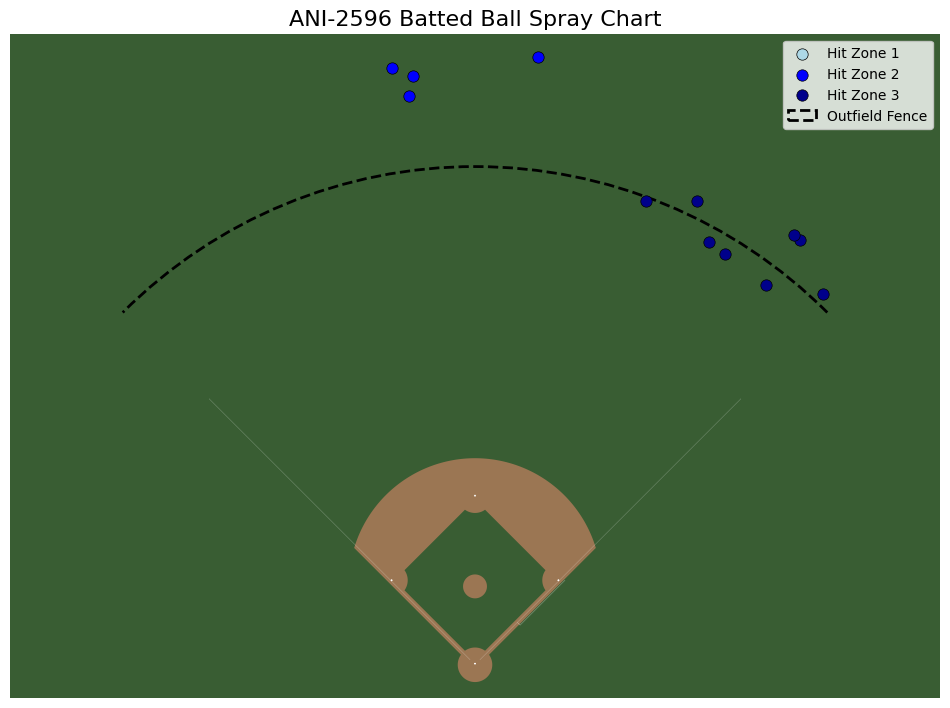

(     Batter  Zone 1%  Zone 2%  Zone 3%  Total Batted Balls
 0  ANI-2596      0.0    33.33    66.67                  12,
 None)

In [118]:
hit_zone_percentage_generator('ANI-2596', is_homerun = True)

### Visualizing batted balls for a sample batter in order to help verify that the batted ball locations make sense

In [119]:
sample_player = hit_zone_generator('ANI-2596')
sample_player

,game_string,inning,half_inning,at_bat,play_per_game,pitcher,batter,on_1b,on_2b,on_3b,timestamp,player_id,ball_eventcode,ball_position_x,ball_position_y,ball_position_z,hit_angles,hit_zone,ROB,is_homerun
0,y1_d067.5_NLG_ANI,1,Bottom,4,14,NLG-0832,ANI-2596,False,False,False,434631,255,11,-46.7388,442.8600,22.572180,96.024611,2,0,True
1,y1_d067.5_NLG_ANI,4,Bottom,32,133,NLG-7756,ANI-2596,True,False,False,4325231,7,2,-137.0616,276.4170,3.355290,116.374552,1,1,False
2,y1_d105_OER_ANI,2,Bottom,21,85,OER-6287,ANI-2596,True,True,False,2723244,3,2,66.9408,104.7858,3.675330,57.428150,3,2,False
3,y1_d105_OER_ANI,4,Bottom,44,180,OER-6287,ANI-2596,False,False,True,5621644,4,2,39.0732,144.0570,-0.095188,74.824530,3,1,False
4,y1_d105.5_OER_ANI,2,Bottom,14,49,OER-5607,ANI-2596,False,False,False,1632312,4,2,95.9760,136.5651,0.416202,54.901000,3,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,y1_d211_QHX_ANI,3,Bottom,30,97,QHX-3109,ANI-2596,True,False,False,3669772,7,2,-126.2778,187.5255,1.788018,123.955931,1,1,False
95,y1_d211_QHX_ANI,4,Bottom,44,152,QHX-3109,ANI-2596,True,False,False,5704072,9,2,163.3176,287.1645,-0.057600,60.372032,3,1,False
96,y1_d211_QHX_ANI,7,Bottom,67,226,QHX-5566,ANI-2596,False,False,False,8797822,3,2,71.0367,98.7639,4.104900,54.274131,3,0,False
97,y1_d212_QHX_ANI,5,Bottom,31,135,QHX-8952,ANI-2596,False,False,False,4558561,4,2,94.8396,151.9974,0.034962,58.037676,3,0,False


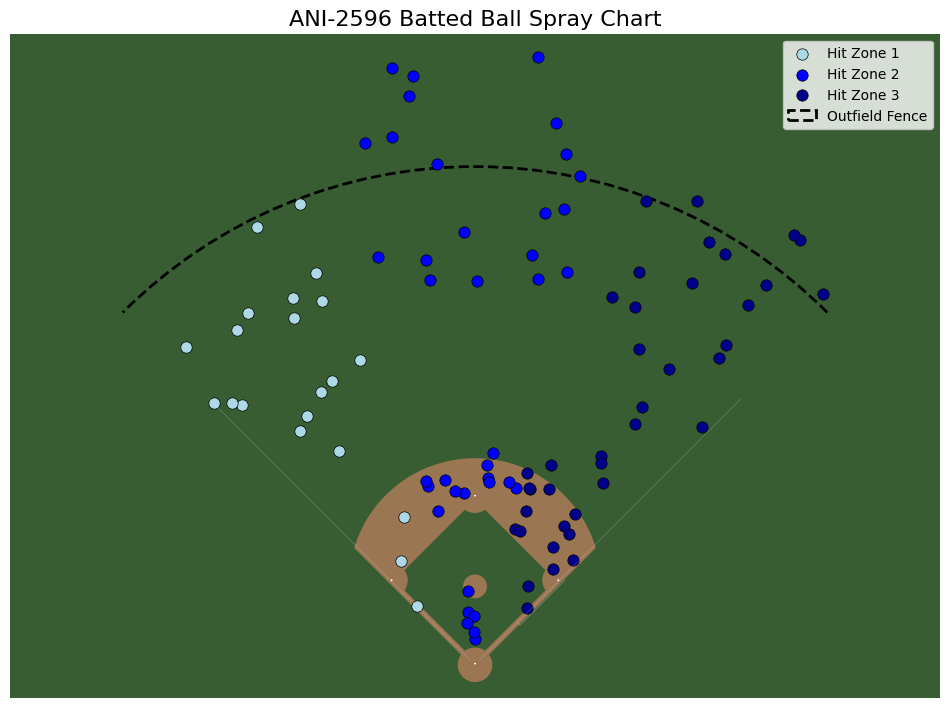

(     Batter  Zone 1%  Zone 2%  Zone 3%  Total Batted Balls
 0  ANI-2596    21.43    38.78     39.8                  98,
 None)

In [120]:
hit_zone_percentage_generator('ANI-2596')

### Batted balls above make sense, only includes fair balls and they all seem to be reasonable in terms of location